# Tarea 3 - Cristóbal Vergara Jofré

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [3]:
from pathlib import Path
import missingno as msno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

data_path = "../../../data/junaeb2n.csv"
df = pd.read_csv(data_path)
display(df.head())


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,2.0,1,16.0,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1.0,1,17.0,15,0,"Exhibe un perfil socioemocional muy solido, de..."


In [4]:
df["edad_anios"] = df["edad"] / 12

print("Columnas:")
print(df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nInfo general:")
df.info()

sk_cols = [f"sk{i}" for i in range(1, 14)]
numeric_cols = ["edad_anios", "imce", "act_fisica", "educm", "educp"]
cat_cols = ["sexo", "vive_padre", "vive_madre", "area", "madre_work"]
print("\nDuplicados exactos:", df.duplicated().sum())

Columnas:
['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13', 'act_fisica', 'area', 'educm', 'educp', 'madre_work', 'narrative', 'edad_anios']

Tipos de datos:
sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
narrative      object
edad_anios    float64
dtype: object

Info general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------    

            n_missing  pct_missing    dtype
act_fisica       1435     3.428585  float64
educm             551     1.316481  float64


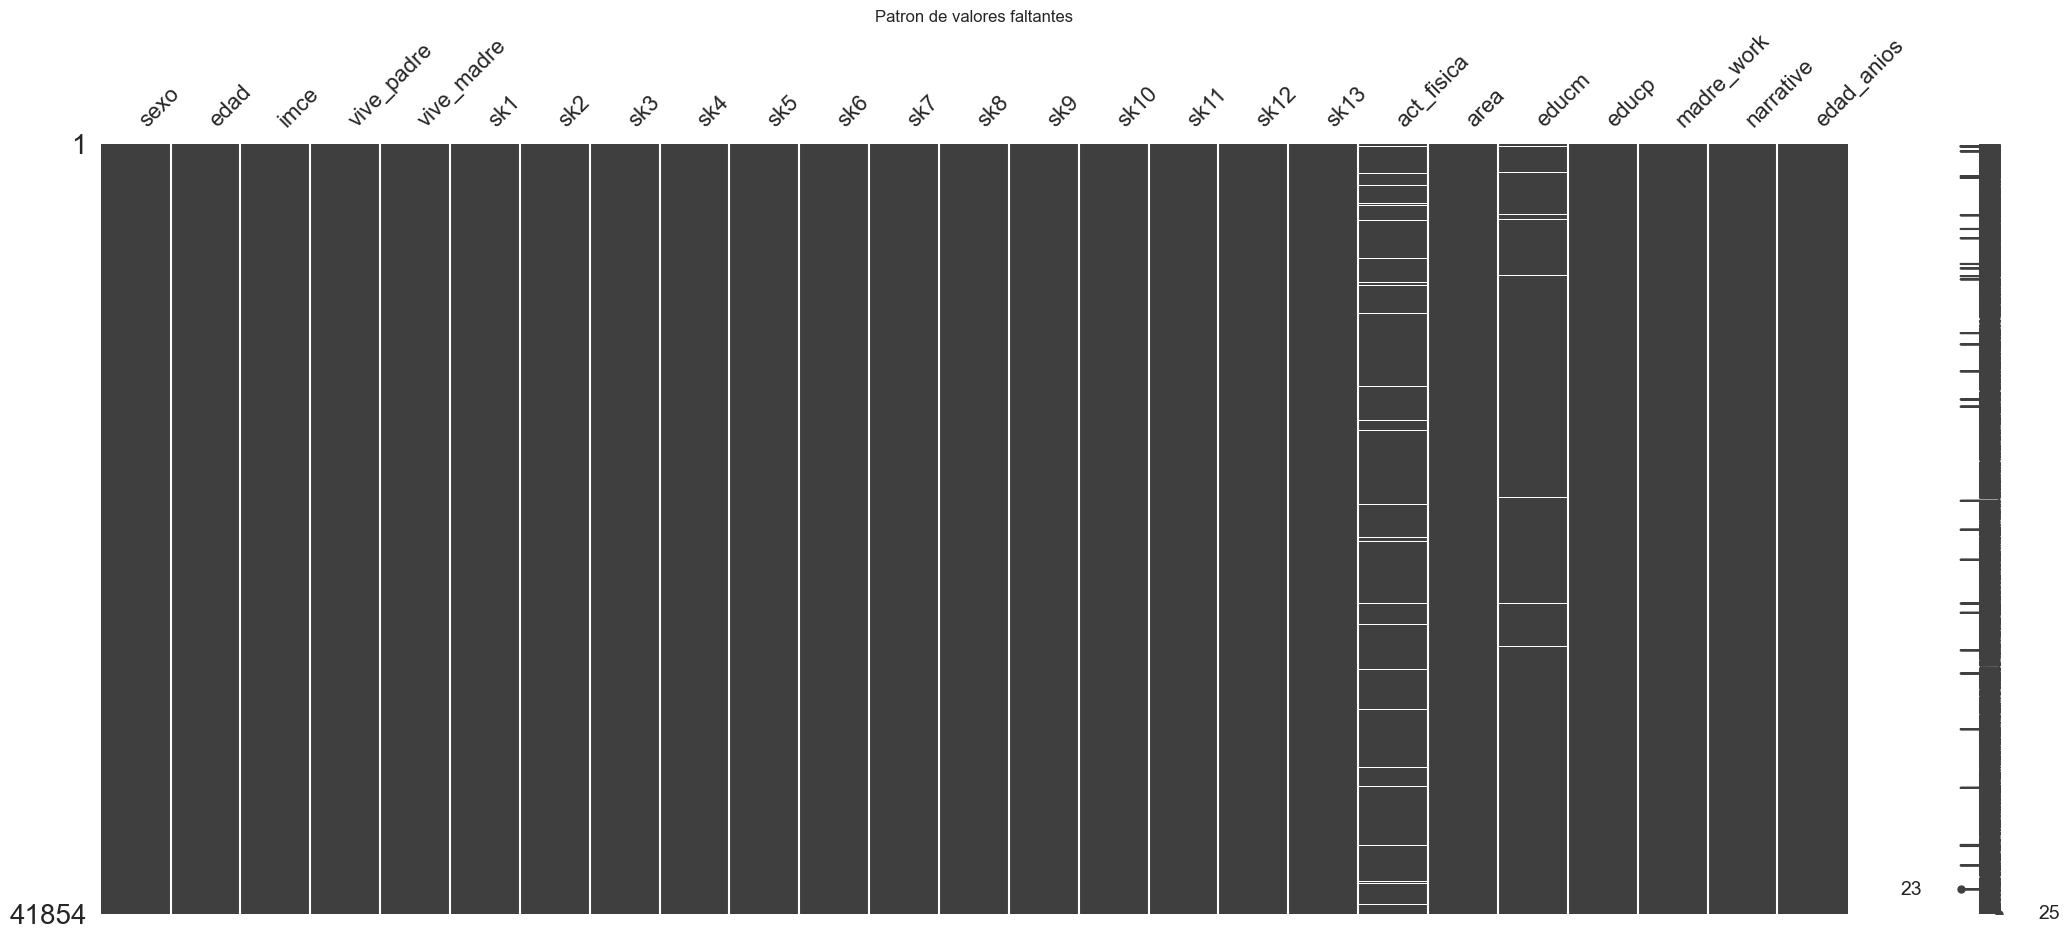

In [5]:
missing = pd.DataFrame(
    {
        "n_missing": df.isna().sum(),
        "pct_missing": 100 * df.isna().mean(),
        "dtype": df.dtypes.astype(str),
    }
).sort_values("n_missing", ascending=False)

print(missing[missing["n_missing"] > 0])
msno.matrix(df)
plt.title("Patron de valores faltantes")
plt.show()


sexo
sexo
0    18737
1    23117
Name: count, dtype: int64
sexo
0    44.77
1    55.23
Name: proportion, dtype: float64

vive_padre
vive_padre
0    11733
1    30105
2       16
Name: count, dtype: int64
vive_padre
0    28.03
1    71.93
2     0.04
Name: proportion, dtype: float64

vive_madre
vive_madre
0     1529
1    40255
2       70
Name: count, dtype: int64
vive_madre
0     3.65
1    96.18
2     0.17
Name: proportion, dtype: float64

area
area
0     3699
1    38155
Name: count, dtype: int64
area
0     8.84
1    91.16
Name: proportion, dtype: float64

madre_work
madre_work
-1    17026
 0     4309
 1    20519
Name: count, dtype: int64
madre_work
-1    40.68
 0    10.30
 1    49.03
Name: proportion, dtype: float64


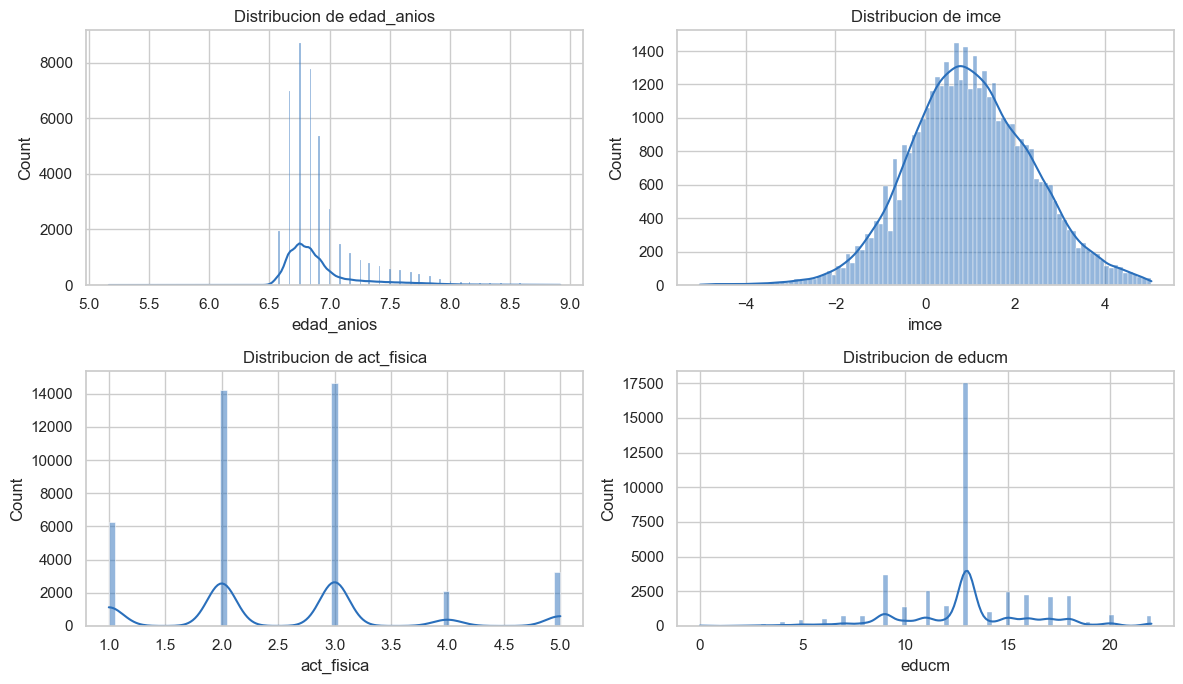

In [6]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print((100 * df[col].value_counts(dropna=False, normalize=True).sort_index()).round(2))

# %%
# Distribuciones numericas mas utiles
plot_num_cols = ["edad_anios", "imce", "act_fisica", "educm"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for i, col in enumerate(plot_num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2a6fbb")
    axes[i].set_title(f"Distribucion de {col}")

plt.tight_layout()
plt.show()

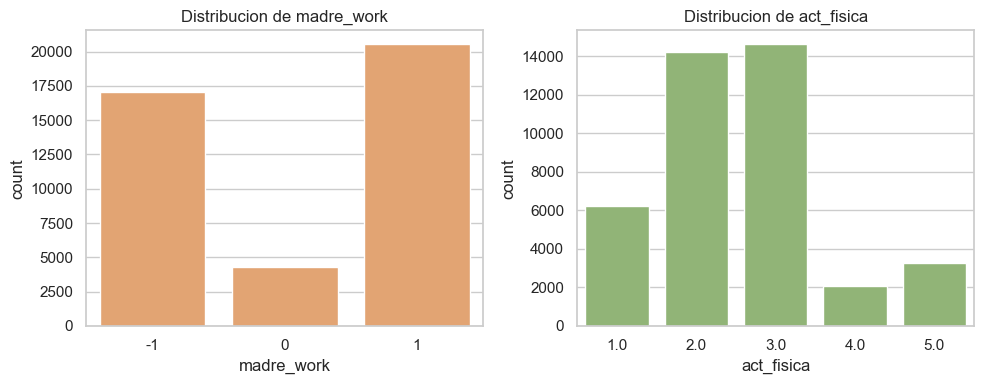

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df, x="madre_work", ax=axes[0], color="#f4a261")
axes[0].set_title("Distribucion de madre_work")

sns.countplot(data=df, x="act_fisica", ax=axes[1], color="#90be6d")
axes[1].set_title("Distribucion de act_fisica")

plt.tight_layout()
plt.show()

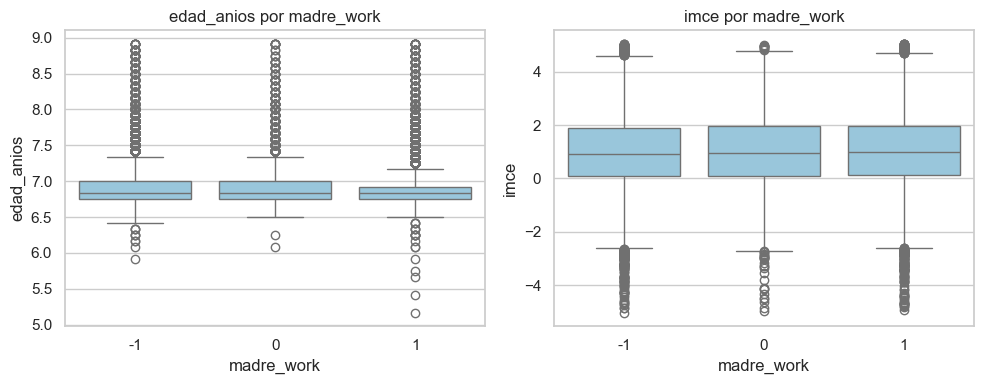

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(["edad_anios", "imce"]):
    sns.boxplot(data=df, x="madre_work", y=col, ax=axes[i], color="#8ecae6")
    axes[i].set_title(f"{col} por madre_work")

plt.tight_layout()
plt.show()

Transformaciones


In [9]:

df_clean = df.copy()

# Indicadores de missing antes de imputar.
df_clean["act_fisica_missing"] = df_clean["act_fisica"].isna().astype(int)
df_clean["educm_missing"] = df_clean["educm"].isna().astype(int)

# Imputacion simple: mediana para variables ordinales/numericas.
df_clean["act_fisica_imp"] = df_clean["act_fisica"].fillna(df_clean["act_fisica"].median())
df_clean["educm_imp"] = df_clean["educm"].fillna(df_clean["educm"].median())

print("Medianas usadas para imputacion:")
print(
    pd.Series(
        {
            "act_fisica": df["act_fisica"].median(),
            "educm": df["educm"].median(),
        }
    )
)

Medianas usadas para imputacion:
act_fisica     2.0
educm         13.0
dtype: float64


In [10]:
# Recodificacion de variables de hogar.
# Los valores 2 en vive_padre/vive_madre indican mas de una figura parental; para presencia se tratan como 1.
df_clean["vive_padre_presente"] = df_clean["vive_padre"].replace({2: 1})
df_clean["vive_madre_presente"] = df_clean["vive_madre"].replace({2: 1})

df_clean["madre_work_label"] = df_clean["madre_work"].map(
    {
        -1: "labor_domestica",
        0: "desempleada",
        1: "empleada",
    }
)



In [11]:
# Recodificacion de sk1-sk13.
# En sk*_pos, valores mas altos representan mejor habilidad socioemocional.
sk_pos_cols = []

for col in sk_cols:
    new_col = f"{col}_pos"
    df_clean[new_col] = 6 - df_clean[col]
    sk_pos_cols.append(new_col)

print(df_clean[sk_cols + sk_pos_cols].head())


   sk1  sk2  sk3  sk4  sk5  sk6  sk7  sk8  sk9  sk10  sk11  sk12  sk13  sk1_pos  sk2_pos  sk3_pos  sk4_pos  sk5_pos  sk6_pos  sk7_pos  \
0    1    1    1    2    1    2    2    1    2     2     2     3     2        5        5        5        4        5        4        4   
1    1    1    1    1    1    1    4    1    1     1     1     1     1        5        5        5        5        5        5        2   
2    2    2    3    2    1    2    3    2    2     3     2     1     3        4        4        3        4        5        4        3   
3    1    1    1    1    1    1    2    1    1     1     1     1     1        5        5        5        5        5        5        4   
4    1    1    1    1    1    1    3    1    1     1     1     1     1        5        5        5        5        5        5        3   

   sk8_pos  sk9_pos  sk10_pos  sk11_pos  sk12_pos  sk13_pos  
0        5        4         4         4         3         4  
1        5        5         5         5         5    

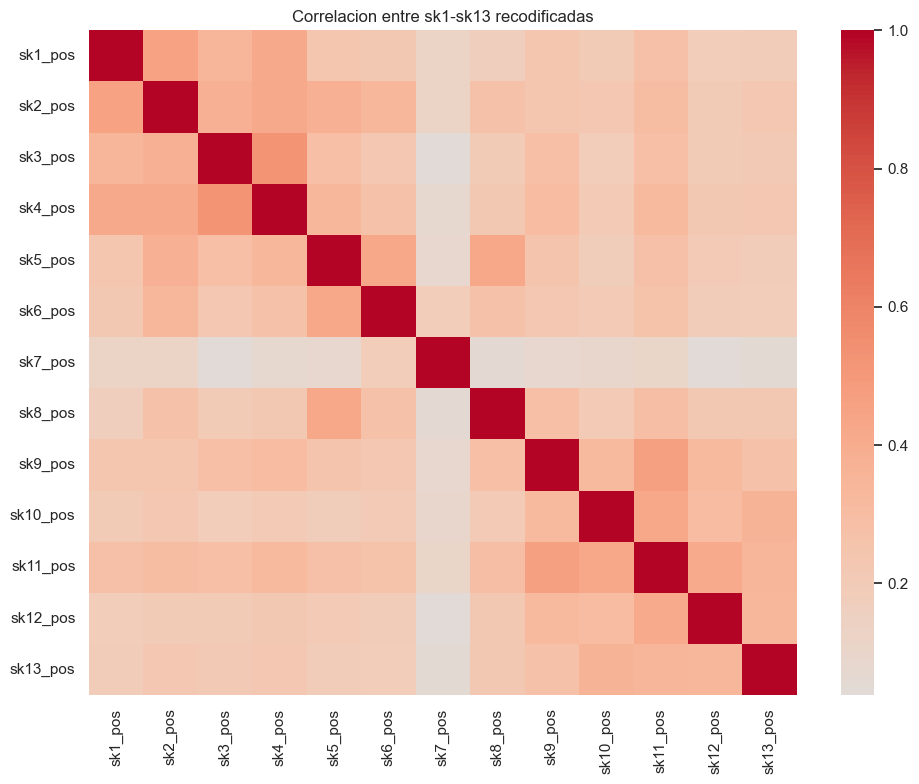

In [12]:
# Correlaciones entre sk recodificadas
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[sk_pos_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlacion entre sk1-sk13 recodificadas")
plt.tight_layout()
plt.show()

R P1: Para la exploracion y transformacion de la base de datos inicial se hizo:
- Se cargó la base de datos junaeb2n.csv revisando columnas, tipos y duplicados.
- Se transformó edad a años para mejor entendimiento.
- Se revisaron nulos/valores faltantes y se encontraron en "act_fisica" y en "educm", para estas columnas se imputó con la mediana en ambos casos ya que son variables numericas y ordinales.
- "vive_madre" y "vive_padre" se transformó para representar presencia parental asi que el valor 2 se trató como presencia y se creó variable binarias "vive_madre_presente" y "vive_padre_presente"
- Las variables sk1 a sk13 se recodificaron para que tengan todas sentido positivo ("sk_pos"), de esta forma valores mas altos indican mejores habilidades socioemocionales
- Se graficaron distribuciones de variables como edad, imce, act_fisica, educm y madre_work para revisar concentración de datos, posibles asimetrías y valores extremos
- También se revisaron frecuencias de variables categóricas como sexo, area, vive_madre, vive_padre y madre_work, para entender la composición general de la muestra.
- No se eliminaron observaciones por outliers, ya que no se observaron valores extremos claramente inválidos. En particular, imce presenta dispersión esperable al ser una variable estandarizada
- Se mantuvo la base original sin modificar y se creó df_clean como copia limpia para las transformaciones posteriores

En general, la base venía bastante completa, por lo que la limpieza principal consistió en tratar pocos valores faltantes y dejar las variables en un formato más interpretable y coherente para el EFA, CFA y los modelos posteriores.

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [13]:
from factor_analyzer import FactorAnalyzer

X_efa = df_clean[sk_pos_cols].copy()

print("Nulos en matriz EFA:")
print(X_efa.isna().sum())

print("\nDimensiones matriz EFA:", X_efa.shape)


Nulos en matriz EFA:
sk1_pos     0
sk2_pos     0
sk3_pos     0
sk4_pos     0
sk5_pos     0
sk6_pos     0
sk7_pos     0
sk8_pos     0
sk9_pos     0
sk10_pos    0
sk11_pos    0
sk12_pos    0
sk13_pos    0
dtype: int64

Dimensiones matriz EFA: (41854, 13)


In [14]:
# Eigenvalues para decidir numero de factores
fa_base = FactorAnalyzer(rotation=None)
fa_base.fit(X_efa)

eigenvalues, _ = fa_base.get_eigenvalues()

eigen_df = pd.DataFrame(
    {
        "factor": range(1, len(eigenvalues) + 1),
        "eigenvalue": eigenvalues,
        "varianza_aprox": eigenvalues / len(eigenvalues),
    }
)

print(eigen_df)

    factor  eigenvalue  varianza_aprox
0        1    4.154266        0.319559
1        2    1.336533        0.102810
2        3    1.099083        0.084545
3        4    0.999493        0.076884
4        5    0.772087        0.059391
5        6    0.701127        0.053933
6        7    0.692127        0.053241
7        8    0.684081        0.052622
8        9    0.596614        0.045893
9       10    0.515524        0.039656
10      11    0.505833        0.038910
11      12    0.487412        0.037493
12      13    0.455821        0.035063


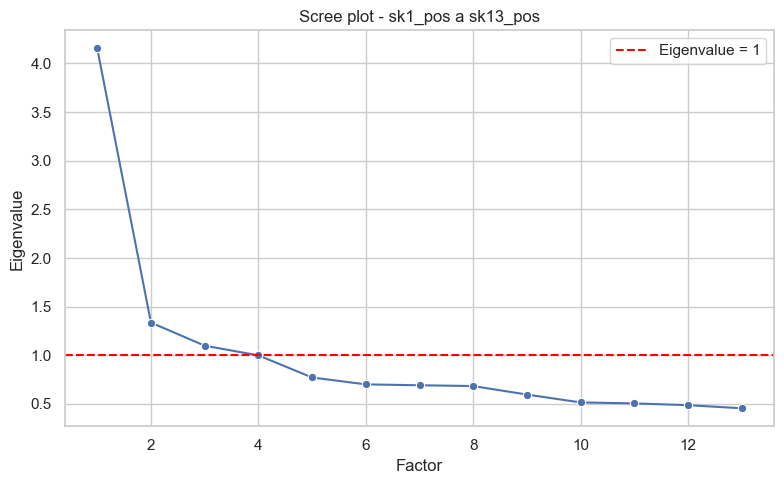

In [15]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=eigen_df, x="factor", y="eigenvalue", marker="o")
plt.axhline(1, color="red", linestyle="--", label="Eigenvalue = 1")
plt.title("Scree plot - sk1_pos a sk13_pos")
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# EFA final: 3 factores por criterio eigenvalue > 1 e interpretabilidad.
n_factors = 3

fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(X_efa)

loadings = pd.DataFrame(
    fa.loadings_,
    index=sk_pos_cols,
    columns=[f"factor_{i+1}" for i in range(n_factors)],
)


factor_colors = {
    "factor_1": "background-color: #cfe8ff; color: #003b73; font-weight: bold",
    "factor_2": "background-color: #d9f2d9; color: #145214; font-weight: bold",
    "factor_3": "background-color: #ffe5c2; color: #7a3b00; font-weight: bold",
}

dominant_factor = loadings.abs().idxmax(axis=1)

loadings_styled = loadings.round(3).style.apply(
    lambda row: [
        factor_colors.get(col, "") if col == dominant_factor.loc[row.name] else ""
        for col in row.index
    ],
    axis=1,
)

display(loadings_styled)

,factor_1,factor_2,factor_3
sk1_pos,0.182000,0.556000,0.156000
sk2_pos,0.176000,0.525000,0.348000
sk3_pos,0.192000,0.599000,0.165000
sk4_pos,0.200000,0.675000,0.201000
sk5_pos,0.119000,0.220000,0.736000
sk6_pos,0.183000,0.215000,0.483000
sk7_pos,0.072000,0.079000,0.137000
sk8_pos,0.268000,0.107000,0.472000
sk9_pos,0.501000,0.224000,0.209000
sk10_pos,0.560000,0.122000,0.130000


In [17]:
communalities = pd.Series(
    fa.get_communalities(),
    index=sk_pos_cols,
    name="comunalidad",
)

factor_variance = pd.DataFrame(
    np.array(fa.get_factor_variance()),
    index=["ss_loadings", "proportion_var", "cumulative_var"],
    columns=[f"factor_{i+1}" for i in range(n_factors)],
)

print(communalities.round(3).to_frame())
print(factor_variance.round(3))

          comunalidad
sk1_pos         0.366
sk2_pos         0.428
sk3_pos         0.423
sk4_pos         0.536
sk5_pos         0.604
sk6_pos         0.312
sk7_pos         0.030
sk8_pos         0.307
sk9_pos         0.345
sk10_pos        0.346
sk11_pos        0.526
sk12_pos        0.316
sk13_pos        0.292
                factor_1  factor_2  factor_3
ss_loadings        1.797     1.662     1.372
proportion_var     0.138     0.128     0.106
cumulative_var     0.138     0.266     0.372


In [18]:
abs_loadings = loadings.abs()

efa_summary = pd.DataFrame(
    {
        "item": sk_pos_cols,
        "factor_principal": abs_loadings.idxmax(axis=1).values,
        "abs_loading_max": abs_loadings.max(axis=1).values,
        "segundo_abs_loading": abs_loadings.apply(lambda row: row.sort_values(ascending=False).iloc[1], axis=1).values,
        "comunalidad": communalities.values,
    }
)

efa_summary["loading_principal"] = [
    loadings.loc[item, factor]
    for item, factor in zip(efa_summary["item"], efa_summary["factor_principal"])
]

efa_summary = efa_summary[
    [
        "item",
        "factor_principal",
        "loading_principal",
        "abs_loading_max",
        "segundo_abs_loading",
        "comunalidad",
    ]
]

print(efa_summary.round(3))

        item factor_principal  loading_principal  abs_loading_max  segundo_abs_loading  comunalidad
0    sk1_pos         factor_2              0.556            0.556                0.182        0.366
1    sk2_pos         factor_2              0.525            0.525                0.348        0.428
2    sk3_pos         factor_2              0.599            0.599                0.192        0.423
3    sk4_pos         factor_2              0.675            0.675                0.201        0.536
4    sk5_pos         factor_3              0.736            0.736                0.220        0.604
5    sk6_pos         factor_3              0.483            0.483                0.215        0.312
6    sk7_pos         factor_3              0.137            0.137                0.079        0.030
7    sk8_pos         factor_3              0.472            0.472                0.268        0.307
8    sk9_pos         factor_1              0.501            0.501                0.224        0.345


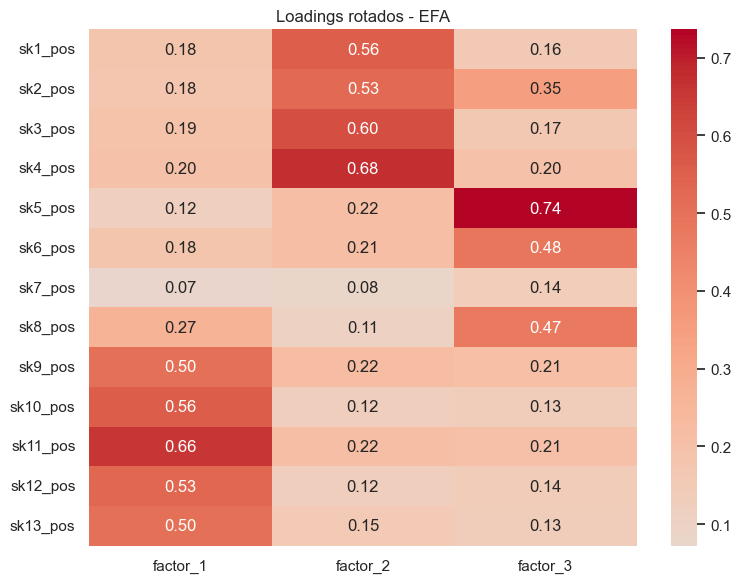

factor_1: ['sk9_pos', 'sk10_pos', 'sk11_pos', 'sk12_pos', 'sk13_pos']
factor_2: ['sk1_pos', 'sk2_pos', 'sk3_pos', 'sk4_pos']
factor_3: ['sk5_pos', 'sk6_pos', 'sk7_pos', 'sk8_pos']


In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Loadings rotados - EFA")
plt.tight_layout()
plt.show()

# %%
for factor in loadings.columns:
    items_factor = efa_summary.loc[efa_summary["factor_principal"] == factor, "item"].tolist()
    print(f"{factor}: {items_factor}")



R P2: Para realizar el analisis factorial exploratorio se usaron las variables transformadas skX_pos. Para decidir el numero de factores se vieron los eigenvalues y el scree plot.Los tres primeros factores tuvieron eigenvalues mayores a 1 (4.154, 1.337 y 1.099), mientras que el cuarto quedó prácticamente en el límite (0.999).Por esto se decidió usar solo 3 factores ya que se revisó usar 4 factores y no se logró ver un grupo claro.

Los loadings mostraron una buena estructura donde se puede observar a simple vista que variables se relacionaban a cada grupo. El primer grupo (sk9 a sk13) se relacionaban a la curiosidad e interes por el entorno. El otro grupo con las variables sk1 a sk4 representaba afectividad y expresion emocional y el tercer grupo con las variables sk5, sk6 y sk8 se relacionaban a la sociabilidad, juego y compartir.

La variable mas problematica fue sk7 cuyo loading mas alto es 0.137 hacia el factor sociable(mas tarde llamado friendly_gang), ademas su comunalidad tambien fue muy baja (0.03) indicando que casi no es explicada por los factores encontrados. otra variable problematica era sk13_pos que presentó una comunalidad algo baja (0.292), aunque su loading principal fue claro y por eso se mantuvo.

En general, la solución de tres factores explicó aproximadamente un 37.2% de la varianza acumulada después de la rotación. Aunque no es una proporción muy alta, los factores resultantes fueron interpretables y consistentes con el contenido de las variables, por lo que se decidió continuar con esta estructura en el CFA, considerando excluir sk7_pos por su bajo aporte.

3. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). Guarde sus predicciones.

In [20]:
import semopy

X_cfa = df_clean[sk_pos_cols].copy()

factor_names = ["affectionate_gang", "friendly_gang", "curiosity_gang"]

model_desc = """
affectionate_gang =~ sk1_pos + sk2_pos + sk3_pos + sk4_pos
friendly_gang =~ sk5_pos + sk6_pos + sk8_pos
curiosity_gang =~ sk9_pos + sk10_pos + sk11_pos + sk12_pos + sk13_pos
"""
print(model_desc)


affectionate_gang =~ sk1_pos + sk2_pos + sk3_pos + sk4_pos
friendly_gang =~ sk5_pos + sk6_pos + sk8_pos
curiosity_gang =~ sk9_pos + sk10_pos + sk11_pos + sk12_pos + sk13_pos



In [21]:
cfa_model = semopy.Model(model_desc)
cfa_result = cfa_model.fit(X_cfa)

print(cfa_result)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.147
Number of iterations: 42
Params: 1.793 1.596 1.751 1.027 1.139 1.306 1.215 1.077 1.265 0.058 0.066 0.172 0.061 0.103 0.173 0.626 0.214 0.459 0.730 0.103 0.252 0.206 0.169 0.158 0.375 0.492 0.294


In [22]:
cfa_params = cfa_model.inspect(std_est=True)

std_col = "Est. Std" if "Est. Std" in cfa_params.columns else "Estimate"

loadings_cfa = cfa_params[
    (cfa_params["op"] == "~")
    & (cfa_params["lval"].isin(sk_pos_cols))
].copy()

loadings_cfa = loadings_cfa[
    ["lval", "rval", "Estimate", std_col, "p-value"]
].rename(
    columns={
        "lval": "item",
        "rval": "factor",
        std_col: "loading_estandarizado",
    }
)

print(loadings_cfa.round(3))

        item             factor  Estimate  loading_estandarizado p-value
0    sk1_pos  affectionate_gang     1.000                  0.600       -
1    sk2_pos  affectionate_gang     1.793                  0.652     0.0
2    sk3_pos  affectionate_gang     1.596                  0.646     0.0
3    sk4_pos  affectionate_gang     1.751                  0.715     0.0
4    sk5_pos      friendly_gang     1.000                  0.723       -
5    sk6_pos      friendly_gang     1.027                  0.572     0.0
6    sk8_pos      friendly_gang     1.139                  0.559     0.0
7    sk9_pos     curiosity_gang     1.000                  0.608       -
8   sk10_pos     curiosity_gang     1.306                  0.565     0.0
9   sk11_pos     curiosity_gang     1.215                  0.736     0.0
10  sk12_pos     curiosity_gang     1.077                  0.551     0.0
11  sk13_pos     curiosity_gang     1.265                  0.523     0.0


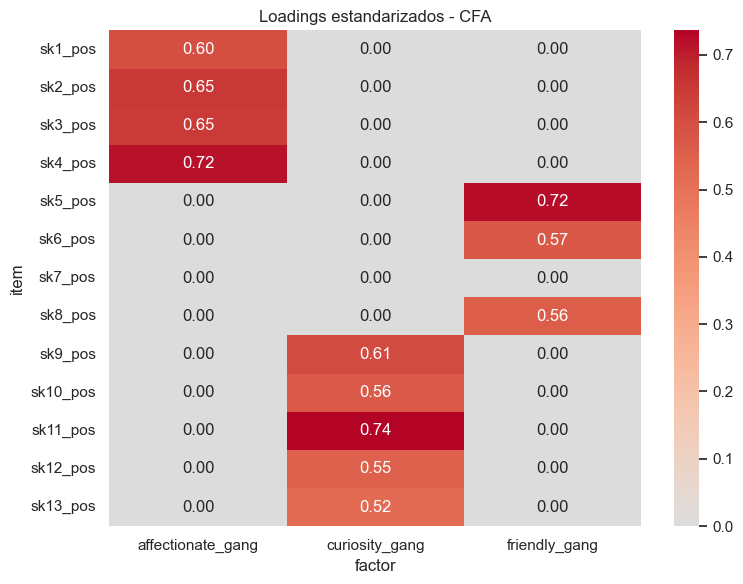

In [23]:
loadings_cfa_wide = (
    loadings_cfa.pivot(index="item", columns="factor", values="loading_estandarizado")
    .reindex(sk_pos_cols)
    .fillna(0)
)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings_cfa_wide, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Loadings estandarizados - CFA")
plt.tight_layout()
plt.show()

In [24]:
fit_stats = semopy.calc_stats(cfa_model)
fit_cols = [
    col
    for col in ["chi2", "DoF", "CFI", "TLI", "RMSEA", "AIC", "BIC", "LogLik"]
    if col in fit_stats.columns
]

print(fit_stats[fit_cols].T.round(3))

           Value
chi2    6148.096
DoF       51.000
CFI        0.949
TLI        0.934
RMSEA      0.053
AIC       53.706
BIC      287.039
LogLik     0.147


                   affectionate_gang  friendly_gang  curiosity_gang
affectionate_gang              1.000          0.658           0.612
friendly_gang                  0.658          1.000           0.596
curiosity_gang                 0.612          0.596           1.000


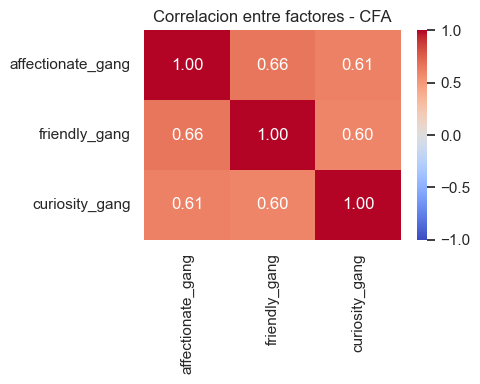

In [25]:
latent_corr_long = cfa_params[
    (cfa_params["op"] == "~~")
    & (cfa_params["lval"].isin(factor_names))
    & (cfa_params["rval"].isin(factor_names))
    & (cfa_params["lval"] != cfa_params["rval"])
].copy()

factor_corr = pd.DataFrame(
    np.eye(len(factor_names)),
    index=factor_names,
    columns=factor_names,
)

for _, row in latent_corr_long.iterrows():
    factor_corr.loc[row["lval"], row["rval"]] = row[std_col]
    factor_corr.loc[row["rval"], row["lval"]] = row[std_col]

print(factor_corr.round(3))

plt.figure(figsize=(5, 4))
sns.heatmap(factor_corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlacion entre factores - CFA")
plt.tight_layout()
plt.show()

In [26]:
factor_scores = cfa_model.predict_factors(X_cfa)

print(factor_scores.head(10))
print(factor_scores.describe().T.round(3))

df_model = pd.concat(
    [
        df_clean.reset_index(drop=True),
        factor_scores.reset_index(drop=True),
    ],
    axis=1,
)


   affectionate_gang  curiosity_gang  friendly_gang
0          -0.046238       -0.362177      -0.001326
1           0.159978        0.352798       0.308103
2          -0.450696       -0.465387      -0.278467
3           0.159978        0.352798       0.308103
4           0.159978        0.352798       0.308103
5           0.072928        0.326467       0.269313
6          -0.125801       -0.753332      -0.465290
7          -0.255969       -0.945983      -1.137010
8          -0.348424       -0.705800      -0.174455
9           0.159978        0.352798       0.308103
                     count  mean    std    min    25%    50%    75%    max
affectionate_gang  41854.0  -0.0  0.214 -2.020 -0.066  0.084  0.145  0.160
curiosity_gang     41854.0   0.0  0.367 -2.767 -0.179  0.112  0.275  0.353
friendly_gang      41854.0  -0.0  0.356 -3.001 -0.151  0.126  0.269  0.308


R P3: Tras obtener los resultados del EFA se propuso el CFA con tres factores y cada variable solo se asocia a un factor. Para esto se excluyó sk7 porque mostró un loading y comunalidad muy baja por lo que no aportaba claramente a ningun factor. Así el modelo final quedó con los factores: "affectionate_gang" asociado a expresion afectiva y emocional(sk1 a sk4), "friendly_gang" asociado a interaccion social y juego con otros niños (sk5, sk6 y sk8) y curiosity_gang asociado a curiosidad, interes por el entorno y exploracion(sk9 a sk13)

En affectionate_gang, los loadings fueron entre 0.600 y 0.715, siendo sk4_pos el indicador más fuerte. En friendly_gang, los loadings fueron 0.723 para sk5_pos, 0.572 para sk6_pos y 0.559 para sk8_pos, por lo que el ítem más representativo fue sk5_pos. En curiosity_gang, los loadings estuvieron entre 0.523 y 0.736, destacando sk11_pos como el indicador más importante. En general, esto indica que todas las variables incluidas aportan razonablemente bien a sus factores

Respecto al ajuste del modelo, los indicadores muestran un ajuste aceptable. El CFI fue 0.949, el TLI fue 0.934 y el RMSEA fue 0.053. Estos valores sugieren que el modelo no es perfecto, pero sí suficientemente razonable para continuar el análisis. El chi2 fue alto (6148.096), aunque esto es esperable considerando el tamaño grande de la muestra

Las correlaciones entre factores fueron positivas y moderadas-altas: affectionate_gang con friendly_gang fue 0.658, affectionate_gang con curiosity_gang fue 0.612, y friendly_gang con curiosity_gang fue 0.596. Esto indica que las dimensiones están relacionadas entre sí, como era esperable al tratarse de habilidades socioemocionales.

Finalmente, se guardaron los puntajes factoriales para cada estudiante. Estos puntajes resumen la posición relativa de cada observación en las tres dimensiones estimadas y luego se incorporaron a df_model para ser usados como variables predictoras en los modelos de clasificación posteriores

4. Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

In [28]:
factor_cols = ["affectionate_gang", "curiosity_gang", "friendly_gang"]

df_rf = df_model[df_model["madre_work"].isin([-1, 1])].copy()
df_rf["target"] = (df_rf["madre_work"] == 1).astype(int)

X = df_rf[factor_cols].copy()
y = df_rf["target"].copy()

print("Distribucion original de madre_work:")
print(df_model["madre_work"].value_counts(dropna=False).sort_index())

print("\nDistribucion usada en P4, excluyendo desempleadas:")
print(df_rf["madre_work"].value_counts(normalize=False).sort_index())


Distribucion original de madre_work:
madre_work
-1    17026
 0     4309
 1    20519
Name: count, dtype: int64

Distribucion usada en P4, excluyendo desempleadas:
madre_work
-1    17026
 1    20519
Name: count, dtype: int64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=67,
    stratify=y,
)

print("Dimensiones:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nProporcion de clases en train:")
print((100 * y_train.value_counts(normalize=True).sort_index()).round(2))

print("\nProporcion de clases en test:")
print((100 * y_test.value_counts(normalize=True).sort_index()).round(2))

Dimensiones:
X_train: (30036, 3)
X_test: (7509, 3)

Proporcion de clases en train:
target
0    45.35
1    54.65
Name: proportion, dtype: float64

Proporcion de clases en test:
target
0    45.35
1    54.65
Name: proportion, dtype: float64


In [30]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=67)

start_time = time.perf_counter()
rf_base.fit(X_train, y_train)
rf_base_train_time = time.perf_counter() - start_time

y_pred_base = rf_base.predict(X_test)

rf_base_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred_base),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_base),
        "precision": precision_score(y_test, y_pred_base, zero_division=0),
        "recall": recall_score(y_test, y_pred_base, zero_division=0),
        "f1": f1_score(y_test, y_pred_base, zero_division=0),
        "train_time_seconds": rf_base_train_time,
    }
)

print(rf_base_metrics.round(3))

print(classification_report(y_test, y_pred_base, target_names=["labor_domestica", "empleada"]))

accuracy              0.524
balanced_accuracy     0.504
precision             0.549
recall                0.718
f1                    0.622
train_time_seconds    4.988
dtype: float64
                 precision    recall  f1-score   support

labor_domestica       0.46      0.29      0.36      3405
       empleada       0.55      0.72      0.62      4104

       accuracy                           0.52      7509
      macro avg       0.50      0.50      0.49      7509
   weighted avg       0.51      0.52      0.50      7509



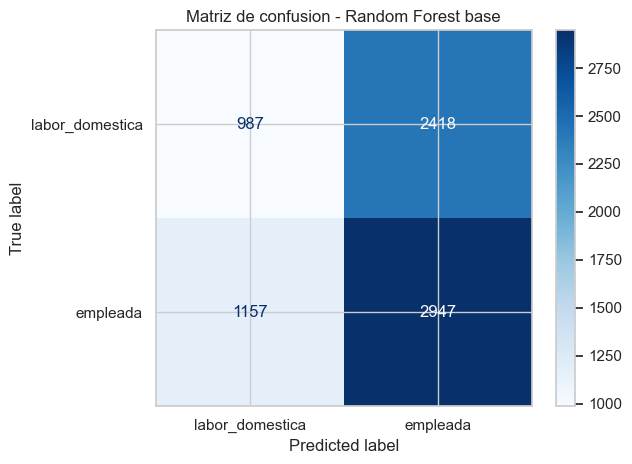

In [31]:
cm_base = confusion_matrix(y_test, y_pred_base, labels=rf_base.classes_)
disp_base = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=["labor_domestica", "empleada"],
)
disp_base.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion - Random Forest base")
plt.tight_layout()
plt.show()

In [35]:
param_grid = {
    "bootstrap": [True],
    "max_depth": [4, 8, 16],
    "max_features": [1, 2],
    "min_samples_leaf": [3, 5],
    "min_samples_split": [2, 6],
    "n_estimators": [100, 200],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

rf_grid = GridSearchCV(
  estimator=RandomForestClassifier(random_state=67),
  param_grid=param_grid,
  cv=cv,
  n_jobs=1,
  verbose=1,
  scoring="accuracy",
)

start_time = time.perf_counter()
rf_grid.fit(X_train, y_train)
rf_grid_train_time = time.perf_counter() - start_time

print("Mejores hiperparametros:")
print(rf_grid.best_params_)
print("\nMejor accuracy promedio en CV:")
print(round(rf_grid.best_score_, 4))
print("\nTiempo de busqueda RF:")
print(round(rf_grid_train_time, 2), "segundos")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores hiperparametros:
{'bootstrap': True, 'max_depth': 4, 'max_features': 1, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}

Mejor accuracy promedio en CV:
0.5529

Tiempo de busqueda RF:
913.5 segundos


In [36]:
rf_cv_results = pd.DataFrame(rf_grid.cv_results_).sort_values("rank_test_score")

display(
    rf_cv_results[
        ["params", "rank_test_score", "mean_test_score", "std_test_score"]
    ].head(10)
)

,params,rank_test_score,mean_test_score,std_test_score
1,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",1,0.552870,0.002029
3,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",1,0.552870,0.002029
0,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",3,0.552803,0.001718
2,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",3,0.552803,0.001718
5,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",5,0.552770,0.002168
7,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",5,0.552770,0.002168
4,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",7,0.552570,0.001773
6,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",7,0.552570,0.001773
9,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",9,0.552104,0.002095
11,"{'bootstrap': True, 'max_depth': 4, 'max_featu...",9,0.552104,0.002095


In [37]:
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
        "precision": precision_score(y_test, y_pred_rf, zero_division=0),
        "recall": recall_score(y_test, y_pred_rf, zero_division=0),
        "f1": f1_score(y_test, y_pred_rf, zero_division=0),
        "grid_train_time_seconds": rf_grid_train_time,
    }
)

print(rf_metrics.round(3))
print(classification_report(y_test, y_pred_rf, target_names=["labor_domestica", "empleada"]))

accuracy                     0.551
balanced_accuracy            0.509
precision                    0.551
recall                       0.963
f1                           0.701
grid_train_time_seconds    913.499
dtype: float64
                 precision    recall  f1-score   support

labor_domestica       0.55      0.06      0.10      3405
       empleada       0.55      0.96      0.70      4104

       accuracy                           0.55      7509
      macro avg       0.55      0.51      0.40      7509
   weighted avg       0.55      0.55      0.43      7509



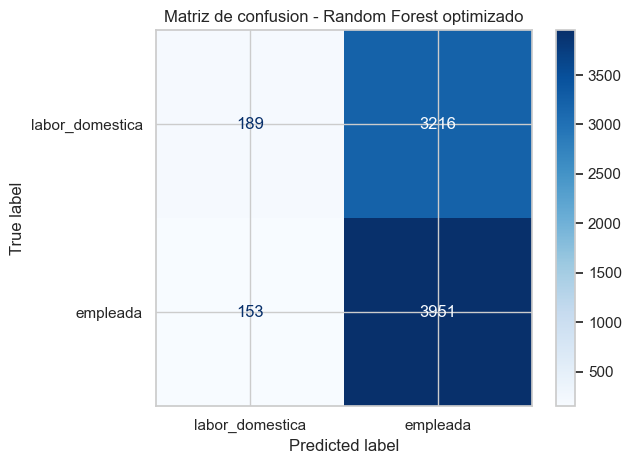

                   importance
curiosity_gang          0.417
affectionate_gang       0.314
friendly_gang           0.269


In [38]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=best_rf.classes_)
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["labor_domestica", "empleada"],
)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion - Random Forest optimizado")
plt.tight_layout()
plt.show()

# %%
rf_feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=factor_cols,
    name="importance",
).sort_values(ascending=False)

print(rf_feature_importance.round(3).to_frame())


R P4: En esta pregunta se usaron como predictores los puntajes factoriales obtenidos en el CFA de la Pregunta 3: affectionate_gang, curiosity_gang y friendly_gang. El objetivo fue clasificar la variable madre_work, excluyendo la categoría de madres desempleadas para transformar el problema en una clasificación binaria entre labor_domestica y empleada. Después de este filtro quedaron 17.026 observaciones de labor doméstica y 20.519 de madres empleadas existiendo cierto desbalance.

Se separó la muestra en entrenamiento y prueba con 80% y 20% respectivamente quedando el conjunto de entrenamiento con 30.036 obs y el de prueba con 7.509. En ambos casos la proporcion fue de 45,35% para labor domestica y 54,65% para empleada dejando la comparacion train/test consistente.

Primero se entrenó un Random Forest base con 100 árboles. Este modelo obtuvo un accuracy de 0.524 y un balanced_accuracy de 0.504, lo que indica un desempeño muy cercano a una clasificación al azar. Además, el reporte por clase mostró que el modelo detecta mejor a las madres empleadas que a las de labor doméstica: el recall para empleada fue 0.72, mientras que para labor doméstica fue solo 0.29.

Luego se realizó una busqueda de hiperparametros con validacion cruzada de 5 pliegues dejando al mejor modelo usando max_depth = 4, max_features = 1, min_samples_leaf = 3, min_samples_split = 2 y n_estimators = 200. El mejor accuracy promedio en validación cruzada fue 0.5529.

En el conjunto de prueba, el Random Forest optimizado obtuvo un accuracy de 0.551, balanced_accuracy de 0.509, precision de 0.551, recall de 0.963 y f1 de 0.701. Aunque el accuracy mejora respecto al modelo base, el balanced_accuracy sigue muy cerca de 0.5, por lo que el modelo no logra separar bien ambas clases. La matriz de confusión y el reporte de clasificación muestran que el modelo tiende fuertemente a predecir la clase empleada: alcanza un recall de 0.96 para esa clase, pero solo 0.06 para labor_domestica.

Respecto a la importancia de variables, el factor más relevante fue curiosity_gang (0.417), seguido por affectionate_gang (0.314) y friendly_gang (0.269). Sin embargo, las diferencias no son muy grandes y, dado el bajo desempeño general, estas importancias deben interpretarse con cautela. En conclusión, los factores socioemocionales estimados en el CFA tienen poca capacidad para clasificar la situación laboral de la madre, y el modelo optimizado termina sesgado hacia la clase mayoritaria.

5. Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).

In [39]:
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Si xgboost no esta instalado, ejecutar antes en terminal o en una celda del notebook:
# python -m pip install xgboost
from xgboost import XGBClassifier

p5_random_state = 67
p5_labels = [0, 1]
p5_target_names = ["labor_domestica", "empleada"]
cv_p5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=p5_random_state)

p5_models = {}
p5_metric_rows = []
p5_grid_results = {}
p5_confusion_matrices = {}
p5_predictions = pd.DataFrame({"y_true": y_test.to_numpy()}, index=y_test.index)


Random Forest - metricas en test


accuracy               0.551
balanced_accuracy      0.509
precision              0.551
recall                 0.963
f1                     0.701
time_seconds         913.499
dtype: float64

                 precision    recall  f1-score   support

labor_domestica       0.55      0.06      0.10      3405
       empleada       0.55      0.96      0.70      4104

       accuracy                           0.55      7509
      macro avg       0.55      0.51      0.40      7509
   weighted avg       0.55      0.55      0.43      7509



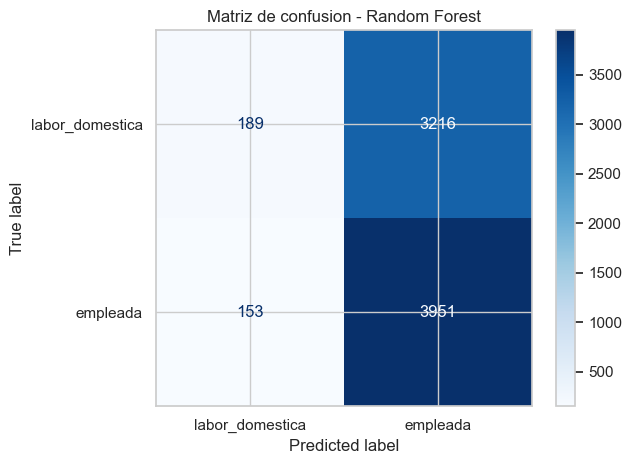

In [40]:
rf_train_time_p5 = (
    float(rf_metrics["grid_train_time_seconds"])
    if "grid_train_time_seconds" in rf_metrics.index
    else float(rf_metrics.get("train_time_seconds", np.nan))
)

y_pred_rf = best_rf.predict(X_test)

p5_models["Random Forest"] = best_rf
p5_predictions["Random Forest"] = y_pred_rf
p5_confusion_matrices["Random Forest"] = confusion_matrix(y_test, y_pred_rf, labels=p5_labels)

rf_p5_metrics = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0),
    "time_seconds": rf_train_time_p5,
}

p5_metric_rows.append(rf_p5_metrics)

print("Random Forest - metricas en test")
display(pd.Series(rf_p5_metrics).drop("model").astype(float).round(3))
print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=p5_labels,
        target_names=p5_target_names,
        zero_division=0,
    )
)

disp_rf_p5 = ConfusionMatrixDisplay(
    confusion_matrix=p5_confusion_matrices["Random Forest"],
    display_labels=p5_target_names,
)
disp_rf_p5.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion - Random Forest")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Gradient Boosting
Mejores hiperparametros:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Mejor balanced_accuracy promedio en CV:
0.5126
Tiempo de busqueda:
279.0 segundos


,params,rank_test_score,mean_test_score,std_test_score
12,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",1,0.512618,0.002198
14,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",2,0.511702,0.003167
15,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",3,0.511573,0.004379
7,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",4,0.511480,0.002522
6,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",5,0.511425,0.000939


Gradient Boosting - metricas en test


accuracy               0.549
balanced_accuracy      0.510
precision              0.552
recall                 0.934
f1                     0.694
time_seconds         278.997
dtype: float64

                 precision    recall  f1-score   support

labor_domestica       0.52      0.08      0.15      3405
       empleada       0.55      0.93      0.69      4104

       accuracy                           0.55      7509
      macro avg       0.53      0.51      0.42      7509
   weighted avg       0.54      0.55      0.45      7509



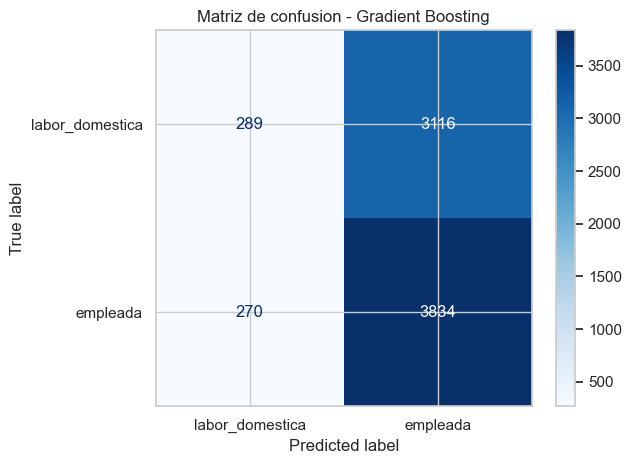

In [41]:
gb_param_grid = {
    "learning_rate": [0.03, 0.1],
    "subsample": [0.7, 1.0],
    "n_estimators": [100, 200],
    "max_depth": [2, 3],
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=p5_random_state),
    param_grid=gb_param_grid,
    cv=cv_p5,
    scoring="balanced_accuracy",
    n_jobs=1,
    verbose=1,
)

start_time = time.perf_counter()
gb_grid.fit(X_train, y_train)
gb_train_time = time.perf_counter() - start_time

best_gb = gb_grid.best_estimator_
p5_grid_results["Gradient Boosting"] = pd.DataFrame(gb_grid.cv_results_).sort_values("rank_test_score")

print("Gradient Boosting")
print("Mejores hiperparametros:")
print(gb_grid.best_params_)
print("Mejor balanced_accuracy promedio en CV:")
print(round(gb_grid.best_score_, 4))
print("Tiempo de busqueda:")
print(round(gb_train_time, 2), "segundos")
display(
    p5_grid_results["Gradient Boosting"][
        ["params", "rank_test_score", "mean_test_score", "std_test_score"]
    ].head(5)
)

y_pred_gb = best_gb.predict(X_test)

p5_models["Gradient Boosting"] = best_gb
p5_predictions["Gradient Boosting"] = y_pred_gb
p5_confusion_matrices["Gradient Boosting"] = confusion_matrix(y_test, y_pred_gb, labels=p5_labels)

gb_metrics = {
    "model": "Gradient Boosting",
    "accuracy": accuracy_score(y_test, y_pred_gb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_gb),
    "precision": precision_score(y_test, y_pred_gb, zero_division=0),
    "recall": recall_score(y_test, y_pred_gb, zero_division=0),
    "f1": f1_score(y_test, y_pred_gb, zero_division=0),
    "time_seconds": gb_train_time,
}

p5_metric_rows.append(gb_metrics)

print("Gradient Boosting - metricas en test")
display(pd.Series(gb_metrics).drop("model").astype(float).round(3))
print(
    classification_report(
        y_test,
        y_pred_gb,
        labels=p5_labels,
        target_names=p5_target_names,
        zero_division=0,
    )
)

disp_gb = ConfusionMatrixDisplay(
    confusion_matrix=p5_confusion_matrices["Gradient Boosting"],
    display_labels=p5_target_names,
)
disp_gb.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion - Gradient Boosting")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 16 candidates, totalling 80 fits
XGBoost
Mejores hiperparametros:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Mejor balanced_accuracy promedio en CV:
0.5127
Tiempo de busqueda:
27.9 segundos


,params,rank_test_score,mean_test_score,std_test_score
14,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",1,0.512677,0.005136
13,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",2,0.512633,0.001748
12,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",3,0.512488,0.001244
6,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",4,0.512007,0.001530
11,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",5,0.511796,0.001312


XGBoost - metricas en test


accuracy              0.545
balanced_accuracy     0.508
precision             0.551
recall                0.904
f1                    0.685
time_seconds         27.896
dtype: float64

                 precision    recall  f1-score   support

labor_domestica       0.49      0.11      0.18      3405
       empleada       0.55      0.90      0.68      4104

       accuracy                           0.54      7509
      macro avg       0.52      0.51      0.43      7509
   weighted avg       0.52      0.54      0.46      7509



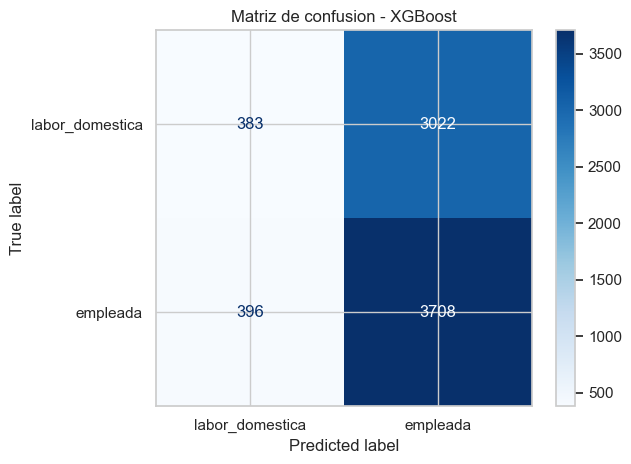

In [42]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=p5_random_state,
        n_jobs=1,
    ),
    param_grid=xgb_param_grid,
    cv=cv_p5,
    scoring="balanced_accuracy",
    n_jobs=1,
    verbose=1,
)

start_time = time.perf_counter()
xgb_grid.fit(X_train, y_train)
xgb_train_time = time.perf_counter() - start_time

best_xgb = xgb_grid.best_estimator_
p5_grid_results["XGBoost"] = pd.DataFrame(xgb_grid.cv_results_).sort_values("rank_test_score")

print("XGBoost")
print("Mejores hiperparametros:")
print(xgb_grid.best_params_)
print("Mejor balanced_accuracy promedio en CV:")
print(round(xgb_grid.best_score_, 4))
print("Tiempo de busqueda:")
print(round(xgb_train_time, 2), "segundos")
display(
    p5_grid_results["XGBoost"][
        ["params", "rank_test_score", "mean_test_score", "std_test_score"]
    ].head(5)
)

y_pred_xgb = best_xgb.predict(X_test)

p5_models["XGBoost"] = best_xgb
p5_predictions["XGBoost"] = y_pred_xgb
p5_confusion_matrices["XGBoost"] = confusion_matrix(y_test, y_pred_xgb, labels=p5_labels)

xgb_metrics = {
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    "precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "recall": recall_score(y_test, y_pred_xgb, zero_division=0),
    "f1": f1_score(y_test, y_pred_xgb, zero_division=0),
    "time_seconds": xgb_train_time,
}

p5_metric_rows.append(xgb_metrics)

print("XGBoost - metricas en test")
display(pd.Series(xgb_metrics).drop("model").astype(float).round(3))
print(
    classification_report(
        y_test,
        y_pred_xgb,
        labels=p5_labels,
        target_names=p5_target_names,
        zero_division=0,
    )
)

disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=p5_confusion_matrices["XGBoost"],
    display_labels=p5_target_names,
)
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion - XGBoost")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 8 candidates, totalling 40 fits
SVM
Mejores hiperparametros:
{'svc__C': 0.01, 'svc__class_weight': 'balanced'}
Mejor balanced_accuracy promedio en CV:
0.5163
Tiempo de busqueda:
1.97 segundos


,params,rank_test_score,mean_test_score,std_test_score
1,"{'svc__C': 0.01, 'svc__class_weight': 'balanced'}",1,0.516264,0.005860
3,"{'svc__C': 0.1, 'svc__class_weight': 'balanced'}",2,0.516190,0.005850
5,"{'svc__C': 1, 'svc__class_weight': 'balanced'}",2,0.516190,0.005850
7,"{'svc__C': 10, 'svc__class_weight': 'balanced'}",4,0.516154,0.005845
4,"{'svc__C': 1, 'svc__class_weight': None}",5,0.511243,0.002260


SVM - metricas en test


accuracy             0.530
balanced_accuracy    0.518
precision            0.561
recall               0.644
f1                   0.600
time_seconds         1.966
dtype: float64

                 precision    recall  f1-score   support

labor_domestica       0.48      0.39      0.43      3405
       empleada       0.56      0.64      0.60      4104

       accuracy                           0.53      7509
      macro avg       0.52      0.52      0.52      7509
   weighted avg       0.52      0.53      0.52      7509



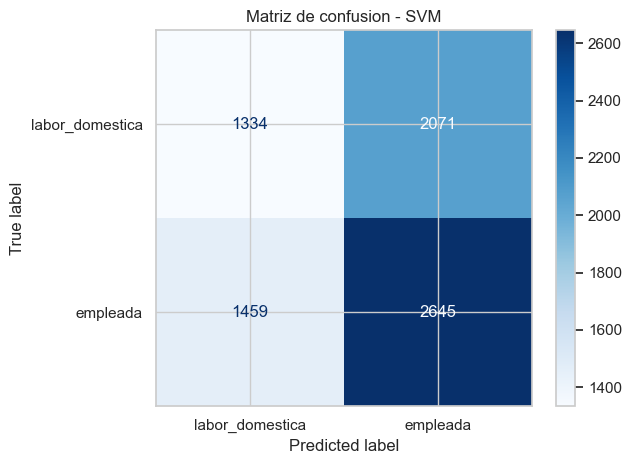

In [44]:
svm_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "svc",
            LinearSVC(random_state=p5_random_state, max_iter=5000, dual=False),
        ),
    ]
)

svm_param_grid = {
    "svc__C": [0.01,0.1, 1, 10],
    "svc__class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv_p5,
    scoring="balanced_accuracy",
    n_jobs=1,
    verbose=1,
)

start_time = time.perf_counter()
svm_grid.fit(X_train, y_train)
svm_train_time = time.perf_counter() - start_time

best_svm = svm_grid.best_estimator_
p5_grid_results["SVM"] = pd.DataFrame(svm_grid.cv_results_).sort_values("rank_test_score")

print("SVM")
print("Mejores hiperparametros:")
print(svm_grid.best_params_)
print("Mejor balanced_accuracy promedio en CV:")
print(round(svm_grid.best_score_, 4))
print("Tiempo de busqueda:")
print(round(svm_train_time, 2), "segundos")
display(
    p5_grid_results["SVM"][
        ["params", "rank_test_score", "mean_test_score", "std_test_score"]
    ].head(5)
)

y_pred_svm = best_svm.predict(X_test)

p5_models["SVM"] = best_svm
p5_predictions["SVM"] = y_pred_svm
p5_confusion_matrices["SVM"] = confusion_matrix(y_test, y_pred_svm, labels=p5_labels)

svm_metrics = {
    "model": "SVM",
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_svm),
    "precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "f1": f1_score(y_test, y_pred_svm, zero_division=0),
    "time_seconds": svm_train_time,
}

p5_metric_rows.append(svm_metrics)

print("SVM - metricas en test")
display(pd.Series(svm_metrics).drop("model").astype(float).round(3))
print(
    classification_report(
        y_test,
        y_pred_svm,
        labels=p5_labels,
        target_names=p5_target_names,
        zero_division=0,
    )
)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=p5_confusion_matrices["SVM"],
    display_labels=p5_target_names,
)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion - SVM")
plt.tight_layout()
plt.show()

Stacking - validacion cruzada


balanced_accuracy_cv_mean    0.511
balanced_accuracy_cv_std     0.002
Name: Stacking, dtype: float64

Stacking - metricas en test


accuracy              0.549
balanced_accuracy     0.508
precision             0.551
recall                0.954
f1                    0.698
time_seconds         34.682
dtype: float64

                 precision    recall  f1-score   support

labor_domestica       0.53      0.06      0.11      3405
       empleada       0.55      0.95      0.70      4104

       accuracy                           0.55      7509
      macro avg       0.54      0.51      0.40      7509
   weighted avg       0.54      0.55      0.43      7509



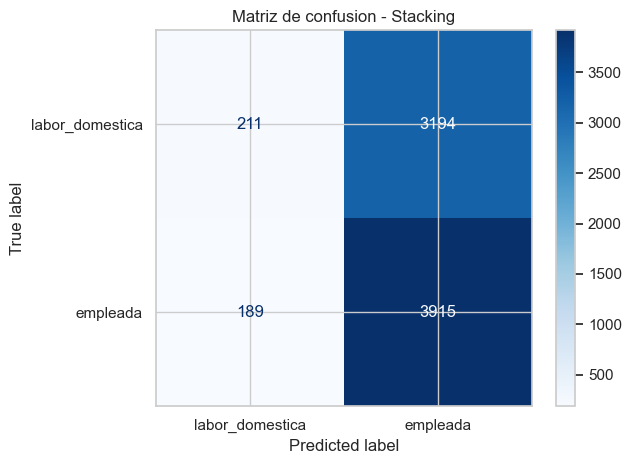

In [45]:
stack_model = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("gb", best_gb),
        ("svc", best_svm),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=p5_random_state),
    cv=cv_p5,
    n_jobs=1,
)

start_time = time.perf_counter()
stack_model.fit(X_train, y_train)
stack_train_time = time.perf_counter() - start_time

stack_cv_scores = cross_val_score(
    stack_model,
    X_train,
    y_train,
    cv=cv_p5,
    scoring="balanced_accuracy",
    n_jobs=1,
)

stacking_cv_summary = pd.Series(
    {
        "balanced_accuracy_cv_mean": stack_cv_scores.mean(),
        "balanced_accuracy_cv_std": stack_cv_scores.std(),
    },
    name="Stacking",
)

print("Stacking - validacion cruzada")
display(stacking_cv_summary.round(3))

y_pred_stack = stack_model.predict(X_test)

p5_models["Stacking"] = stack_model
p5_predictions["Stacking"] = y_pred_stack
p5_confusion_matrices["Stacking"] = confusion_matrix(y_test, y_pred_stack, labels=p5_labels)

stack_metrics = {
    "model": "Stacking",
    "accuracy": accuracy_score(y_test, y_pred_stack),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_stack),
    "precision": precision_score(y_test, y_pred_stack, zero_division=0),
    "recall": recall_score(y_test, y_pred_stack, zero_division=0),
    "f1": f1_score(y_test, y_pred_stack, zero_division=0),
    "time_seconds": stack_train_time,
}

p5_metric_rows.append(stack_metrics)

print("Stacking - metricas en test")
display(pd.Series(stack_metrics).drop("model").astype(float).round(3))
print(
    classification_report(
        y_test,
        y_pred_stack,
        labels=p5_labels,
        target_names=p5_target_names,
        zero_division=0,
    )
)

disp_stack = ConfusionMatrixDisplay(
    confusion_matrix=p5_confusion_matrices["Stacking"],
    display_labels=p5_target_names,
)
disp_stack.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion - Stacking")
plt.tight_layout()
plt.show()

In [46]:
p5_results = (
    pd.DataFrame(p5_metric_rows)
    .set_index("model")
    [
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "time_seconds",
        ]
    ]
    .sort_values("balanced_accuracy", ascending=False)
)

print(p5_results.round(3))

best_model_name = p5_results.index[0]
best_model = p5_models[best_model_name]

print("Mejor modelo segun balanced_accuracy:", best_model_name)
print("Objetos guardados para P7:")
print("best_model_name, best_model, p5_results, p5_predictions")




                   accuracy  balanced_accuracy  precision  recall     f1  time_seconds
model                                                                                 
SVM                   0.530              0.518      0.561   0.644  0.600         1.966
Gradient Boosting     0.549              0.510      0.552   0.934  0.694       278.997
Random Forest         0.551              0.509      0.551   0.963  0.701       913.499
XGBoost               0.545              0.508      0.551   0.904  0.685        27.896
Stacking              0.549              0.508      0.551   0.954  0.698        34.682
Mejor modelo segun balanced_accuracy: SVM
Objetos guardados para P7:
best_model_name, best_model, p5_results, p5_predictions


R P5: En esta pregunta se compararó lo obtenido en la pregunta 4 (Random Forest) con otros modelos: Gradient Boosting, XGBoost, SVM y Stacking. Para evaluar se usó el mismo conjunto de entrenamiento y prueba para todos los modelos.

Al ver accuracy, los resultados fueron muy parecidos entre si. RF obtuvo 0,551, Stacking 0,549, SVM 0,530, Gradient Boosting 0,549 y XGBoost 0,545. A primera vista todos los modelos tuvieron un desempeño parecido y un poco superior al azar.
Sin embargo conviene revisar tambien el balanced accuracy, esta metrica calcula el promedio del recall de cada clase. Esta métrica es útil porque evalúa si el modelo reconoce razonablemente tanto a madres empleadas como a madres en labor doméstica. En este caso, el mejor modelo fue SVM, con un balanced_accuracy de 0.518. Aunque sigue siendo bajo y cercano a 
0,5, fue el modelo que logró el mejor equilibrio entre ambas clases.

La diferencia se observa en la matriz de confusion y el reporte de clasificacion. RF,GradientBoosting y Stacking tienen mayor accuracy y F1, pero tienen a predecir casi todo como empleada.Por ejemplo, Random Forest tiene recall de 0.963 para empleada, pero solo 0.06 para labor doméstica. En cambio, SVM logra un recall de 0.39 para labor doméstica y 0.64 para empleada. No es un gran desempeño, pero sí es menos sesgado hacia una sola clase

En términos de tiempo de ejecución, SVM con LinearSVC fue claramente el más eficiente, tardando solo 1.966 segundos. Esto fue una mejora importante respecto al SVC clasico, que demoraba demasiado en ejecutarse. Además, para que la comparación fuera computacionalmente mas ágil, se usaron grillas de hiperparámetros más acotadas que las usadas en notebooks de las clases. Es decir, se mantuvo la lógica de optimización con validación cruzada, pero reduciendo la cantidad de combinaciones para evitar tiempos de ejecución excesivos. XGBoost también fue rápido, con 27.896 segundos, seguido por Stacking con 34.682 segundos. En cambio, Gradient Boosting tardó 278.997 segundos y Random Forest fue el más lento, con 913.499 segundos (aprox 15 minutos)

En conclusión, SVM fue seleccionado como el mejor modelo, ya que obtuvo el mayor balanced_accuracy y además fue el más rápido. Aun así, el desempeño general sigue siendo bajo, lo que se observa en que todos los modelos tienen métricas cercanas al azar. Esto sugiere que los factores socioemocionales no logran distinguir claramente entre madres empleadas y madres dedicadas a labor doméstica. Una posible explicación es que ambas categorías implican formas de trabajo, responsabilidades, tareas, estrés y desgaste que pueden variar según el caso, y que incluso podrían ser de magnitud similar. Por esto, estas categorías no generarían diferencias suficientemente claras en las habilidades socioemocionales medidas en los niños. Esta interpretación debe entenderse solo como una hipótesis descriptiva, no como una conclusión causal



6. Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?

In [47]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

cluster_df = df_model[["imce", "act_fisica_imp"]].copy()
cluster_df = cluster_df.rename(columns={"act_fisica_imp": "act_fisica"})

print("Nulos en variables de clustering:")
print(cluster_df.isna().sum())

print("\nDescriptivas variables de clustering:")
print(cluster_df.describe().T.round(3))


Nulos en variables de clustering:
imce          0
act_fisica    0
dtype: int64

Descriptivas variables de clustering:
              count   mean    std   min  25%   50%   75%   max
imce        41854.0  1.014  1.380 -5.02  0.1  0.97  1.93  5.04
act_fisica  41854.0  2.534  1.056  1.00  2.0  2.00  3.00  5.00


In [48]:
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(cluster_df)

cluster_scores = []
silhouette_sample = min(5000, len(cluster_df))

for k in range(2, 7):
    kmeans_k = KMeans(n_clusters=k, random_state=67, n_init=20)
    labels_k = kmeans_k.fit_predict(X_cluster)

    cluster_scores.append(
        {
            "k": k,
            "inertia": kmeans_k.inertia_,
            "silhouette": silhouette_score(
                X_cluster,
                labels_k,
                sample_size=silhouette_sample,
                random_state=67,
            ),
        }
    )

cluster_scores_df = pd.DataFrame(cluster_scores)
print(cluster_scores_df.round(3))

   k    inertia  silhouette
0  2  56098.551       0.342
1  3  36788.414       0.382
2  4  28467.534       0.377
3  5  22721.238       0.374
4  6  18718.358       0.388


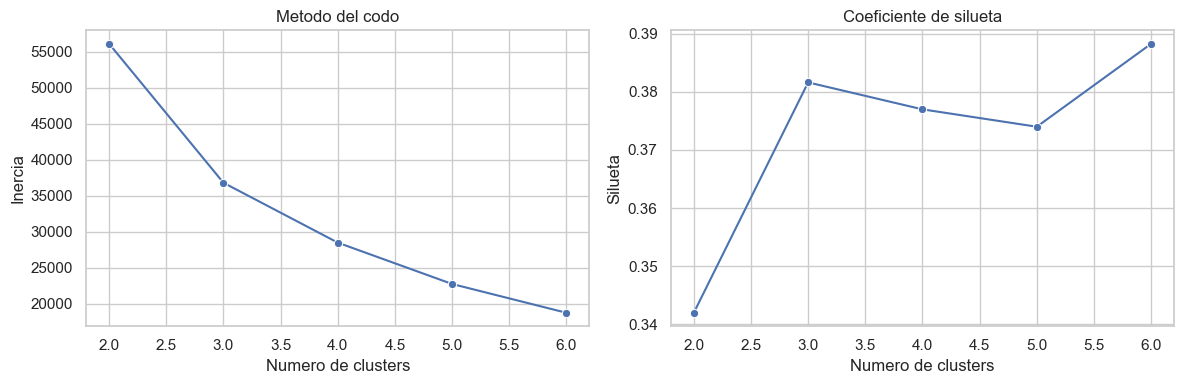

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=cluster_scores_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Metodo del codo")
axes[0].set_xlabel("Numero de clusters")
axes[0].set_ylabel("Inercia")

sns.lineplot(data=cluster_scores_df, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("Numero de clusters")
axes[1].set_ylabel("Silueta")

plt.tight_layout()
plt.show()

In [50]:
k_final = 3

kmeans = KMeans(n_clusters=k_final, random_state=67, n_init=20)
df_model["cluster_imce_af"] = kmeans.fit_predict(X_cluster)
cluster_df["cluster_imce_af"] = df_model["cluster_imce_af"].values

cluster_centers = pd.DataFrame(
    scaler_cluster.inverse_transform(kmeans.cluster_centers_),
    columns=["imce", "act_fisica"],
)
cluster_centers["cluster_imce_af"] = cluster_centers.index

print("Centroides en escala original:")
print(cluster_centers[["cluster_imce_af", "imce", "act_fisica"]].round(3))

Centroides en escala original:
   cluster_imce_af   imce  act_fisica
0                0  0.010       2.225
1                1  2.224       2.247
2                2  0.878       4.624


In [59]:
cluster_summary = df_model.groupby("cluster_imce_af").agg(
    n=("cluster_imce_af", "size"),
    imce_mean=("imce", "mean"),
    imce_std=("imce", "std"),
    act_fisica_mean=("act_fisica_imp", "mean"),
    act_fisica_std=("act_fisica_imp", "std"),
)

cluster_summary["pct"] = 100 * cluster_summary["n"] / len(df_model)
cluster_summary = cluster_summary[
    ["n", "pct", "imce_mean", "imce_std", "act_fisica_mean", "act_fisica_std"]
].sort_values("imce_mean")

print(cluster_summary.round(3))



high_imce_cluster = cluster_summary["imce_mean"].idxmax()

print("Cluster KMeans elegido por mayor IMCE promedio:", high_imce_cluster)
print(cluster_summary.loc[[high_imce_cluster]].round(3))


                     n     pct  imce_mean  imce_std  act_fisica_mean  act_fisica_std
cluster_imce_af                                                                     
0                19714  47.102      0.011     0.858            2.228           0.724
2                 5229  12.493      0.880     1.268            4.624           0.484
1                16911  40.405      2.225     0.845            2.244           0.728
Cluster KMeans elegido por mayor IMCE promedio: 1
                     n     pct  imce_mean  imce_std  act_fisica_mean  act_fisica_std
cluster_imce_af                                                                     
1                16911  40.405      2.225     0.845            2.244           0.728


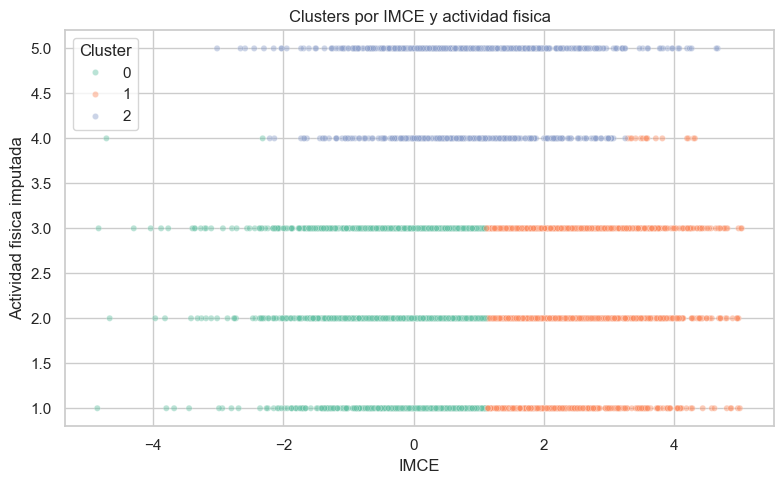

In [52]:
plot_cluster = df_model[["imce", "act_fisica_imp", "cluster_imce_af"]].sample(
    n=min(6000, len(df_model)),
    random_state=67,
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_cluster,
    x="imce",
    y="act_fisica_imp",
    hue="cluster_imce_af",
    palette="Set2",
    alpha=0.45,
    s=20,
)
plt.title("Clusters por IMCE y actividad fisica")
plt.xlabel("IMCE")
plt.ylabel("Actividad fisica imputada")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

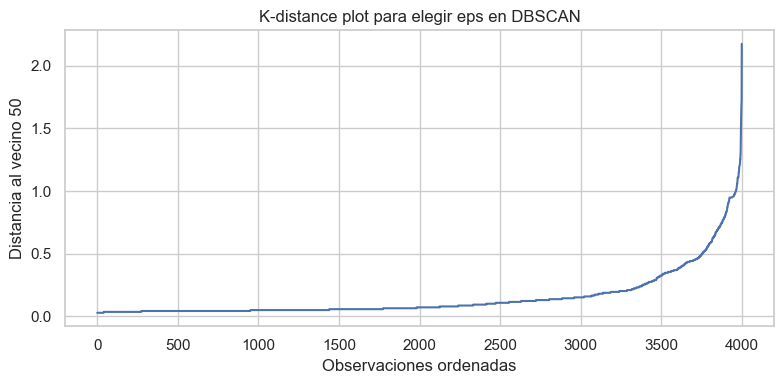

In [54]:
dbscan_min_samples = 50
dbscan_sample_size = min(4000, len(cluster_df))
dbscan_sample_pos = np.random.default_rng(67).choice(
    len(cluster_df),
    size=dbscan_sample_size,
    replace=False,
)
X_cluster_sample = X_cluster[dbscan_sample_pos]

neighbors = NearestNeighbors(n_neighbors=dbscan_min_samples, algorithm="kd_tree")
neighbors.fit(X_cluster_sample)
distances, _ = neighbors.kneighbors(X_cluster_sample)
k_distance = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distance)
plt.title("K-distance plot para elegir eps en DBSCAN")
plt.xlabel("Observaciones ordenadas")
plt.ylabel(f"Distancia al vecino {dbscan_min_samples}")
plt.tight_layout()
plt.show()

In [55]:
eps_candidates = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25]
dbscan_rows = []

for eps in eps_candidates:
    dbscan_try = DBSCAN(
        eps=eps,
        min_samples=dbscan_min_samples,
        algorithm="kd_tree",
    )
    labels_try = dbscan_try.fit_predict(X_cluster_sample)

    n_clusters_try = len(set(labels_try)) - (1 if -1 in labels_try else 0)
    noise_pct_try = 100 * np.mean(labels_try == -1)

    if n_clusters_try >= 2 and noise_pct_try < 95:
        silhouette_try = silhouette_score(X_cluster_sample, labels_try)
    else:
        silhouette_try = np.nan

    dbscan_rows.append(
        {
            "eps": eps,
            "min_samples": dbscan_min_samples,
            "n_clusters": n_clusters_try,
            "noise_pct": noise_pct_try,
            "silhouette": silhouette_try,
        }
    )

dbscan_results_df = pd.DataFrame(dbscan_rows)
print(dbscan_results_df.round(3))

    eps  min_samples  n_clusters  noise_pct  silhouette
0  0.05           50          10     64.350      -0.214
1  0.08           50           4     39.525       0.012
2  0.10           50           3     35.625       0.094
3  0.12           50           4     28.875       0.122
4  0.15           50           4     20.475       0.201
5  0.20           50           4     13.825       0.260
6  0.25           50           4     11.500       0.270


In [56]:
dbscan_valid = dbscan_results_df.dropna(subset=["silhouette"])

if len(dbscan_valid) > 0:
    dbscan_eps = dbscan_valid.sort_values(
        ["silhouette", "n_clusters"],
        ascending=[False, True],
    ).iloc[0]["eps"]
else:
    dbscan_eps = 0.15

print("eps elegido para DBSCAN:", dbscan_eps)
print("min_samples usado:", dbscan_min_samples)

dbscan = DBSCAN(
    eps=dbscan_eps,
    min_samples=dbscan_min_samples,
    algorithm="kd_tree",
)

df_model["cluster_dbscan_imce_af"] = dbscan.fit_predict(X_cluster)
cluster_df["cluster_dbscan_imce_af"] = df_model["cluster_dbscan_imce_af"].values

print("Distribucion de clusters DBSCAN:")
display(df_model["cluster_dbscan_imce_af"].value_counts().sort_index())

eps elegido para DBSCAN: 0.25
min_samples usado: 50
Distribucion de clusters DBSCAN:


cluster_dbscan_imce_af
-1      194
 0    15606
 1     3220
 2     6197
 3     2043
 4    14594
Name: count, dtype: int64

                            n     pct  imce_mean  imce_std  act_fisica_mean  act_fisica_std
cluster_dbscan_imce_af                                                                     
-1                        194   0.464     -2.315     3.027            2.995           1.491
 1                       3220   7.693      0.934     1.260            5.000           0.000
 3                       2043   4.881      0.945     1.256            4.000           0.000
 4                      14594  34.869      1.029     1.362            3.000           0.000
 0                      15606  37.287      1.046     1.360            2.000           0.000
 2                       6197  14.806      1.065     1.363            1.000           0.000
En DBSCAN, el cluster -1 corresponde a observaciones marcadas como ruido.


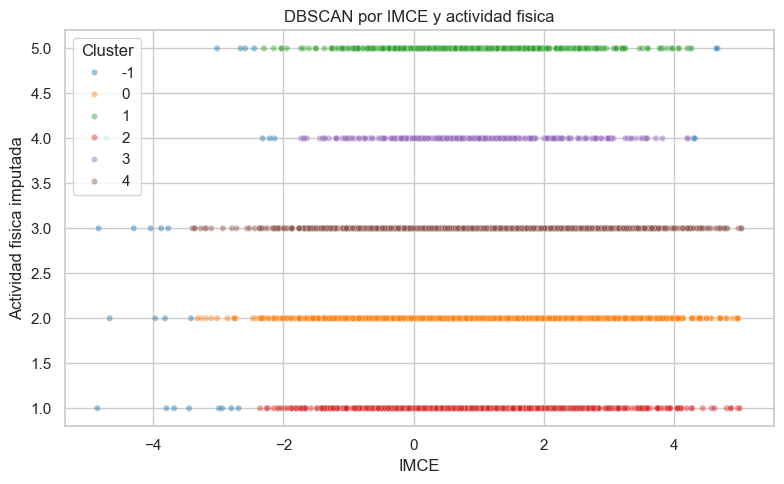

In [57]:
dbscan_summary = df_model.groupby("cluster_dbscan_imce_af").agg(
    n=("cluster_dbscan_imce_af", "size"),
    imce_mean=("imce", "mean"),
    imce_std=("imce", "std"),
    act_fisica_mean=("act_fisica_imp", "mean"),
    act_fisica_std=("act_fisica_imp", "std"),
)

dbscan_summary["pct"] = 100 * dbscan_summary["n"] / len(df_model)
dbscan_summary = dbscan_summary[
    ["n", "pct", "imce_mean", "imce_std", "act_fisica_mean", "act_fisica_std"]
].sort_values("imce_mean")

print(dbscan_summary.round(3))

print("En DBSCAN, el cluster -1 corresponde a observaciones marcadas como ruido.")


plot_dbscan = df_model[["imce", "act_fisica_imp", "cluster_dbscan_imce_af"]].sample(
    n=min(6000, len(df_model)),
    random_state=67,
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_dbscan,
    x="imce",
    y="act_fisica_imp",
    hue="cluster_dbscan_imce_af",
    palette="tab10",
    alpha=0.45,
    s=20,
)
plt.title("DBSCAN por IMCE y actividad fisica")
plt.xlabel("IMCE")
plt.ylabel("Actividad fisica imputada")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

R P6: Para esta pregunta que corresponde a clusterizacion se usaron las variables "imce" y "act_fisica_imp", esta ultima es la version imputada de "act_fisica" Antes de aplicar clustering, ambas variables fueron estandarizadas con StandardScaler, porque están en escalas distintas y KMeans depende de distancias.

Primero se aplicó Kmeans y se evaluaron k = 2 a 6 usando inercia y coeficiente de silueta, Al observar silueta esta fue 0.342 para k=2, subió de forma importante a 0.382 con k=3, y luego bajó levemente para k=4 (0.377) y k=5 (0.374). Aunque k=6 tuvo una silueta algo mayor (0.388), el aumento inicial hasta k=3 fue el cambio más claro del gráfico por esto se decidio usar k=3, ya que representa un punto razonable para la separacion de grupos ya que mejora mucho en relacion a k=2.

Con KMeans y k=3, se obtuvieron tres grupos. El cluster 0 concentra el 47.1% de la muestra, con IMCE promedio bajo/cercano a cero (0.011) y actividad física baja-media (2.228). El cluster 1 representa el 40.4% de la muestra y tiene el mayor IMCE promedio (2.225), pero una actividad física similarmente baja-media (2.244). Finalmente, el cluster 2 contiene el 12.5% de la muestra, con IMCE intermedio (0.880) y actividad física alta (4.624). Por lo tanto, KMeans permite distinguir principalmente entre un grupo de bajo IMCE, un grupo de alto IMCE y baja/moderada actividad física, y un grupo más pequeño con alta actividad física.

También se probó DBSCAN como método alternativo. Este método eligió eps = 0.25 y min_samples = 50. Sin embargo, sus resultados fueron menos útiles para la interpretación del problema, porque terminó separando casi directamente según los niveles discretos de act_fisica. Esto se observa en que varios clusters tienen desviación estándar de actividad física igual a 0, es decir, cada cluster corresponde prácticamente a un solo nivel de actividad física. Además, los promedios de IMCE entre esos clusters fueron muy parecidos, aproximadamente entre 0.934 y 1.065, salvo el grupo de ruido -1.

En conclusión, KMeans entrega una segmentación más clara e interpretable para esta pregunta. DBSCAN sirvió como comparación, pero no generó perfiles sustantivamente distintos en términos de IMCE, sino que reflejó principalmente la naturaleza discreta de la variable actividad física. Por esto, para la siguiente pregunta se decidió continuar con los clusters de KMeans, específicamente con el cluster 1, que fue el grupo con mayor IMCE promedio.


7. Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?

In [60]:
from sklearn.base import clone

print("Cluster KMeans elegido por mayor IMCE promedio:", high_imce_cluster)
print(cluster_summary.loc[[high_imce_cluster]].round(3))

df_p7 = df_model[
    (df_model["cluster_imce_af"] == high_imce_cluster)
    & (df_model["madre_work"].isin([-1, 1]))
].copy()

df_p7["target"] = (df_p7["madre_work"] == 1).astype(int)

print("Dimensiones muestra P7:", df_p7.shape)
print("\nDistribucion madre_work en cluster elegido:")
print(df_p7["madre_work"].value_counts().sort_index())
print((100 * df_p7["madre_work"].value_counts(normalize=True).sort_index()).round(2))

# %%
X_p7 = df_p7[factor_cols].copy()
y_p7 = df_p7["target"].copy()

X_train_p7, X_test_p7, y_train_p7, y_test_p7 = train_test_split(
    X_p7,
    y_p7,
    test_size=0.20,
    random_state=p5_random_state,
    stratify=y_p7,
)

print("Train P7:", X_train_p7.shape, y_train_p7.shape)
print("Test P7:", X_test_p7.shape, y_test_p7.shape)



Cluster KMeans elegido por mayor IMCE promedio: 1
                     n     pct  imce_mean  imce_std  act_fisica_mean  act_fisica_std
cluster_imce_af                                                                     
1                16911  40.405      2.225     0.845            2.244           0.728
Dimensiones muestra P7: (15123, 51)

Distribucion madre_work en cluster elegido:
madre_work
-1    6679
 1    8444
Name: count, dtype: int64
madre_work
-1    44.16
 1    55.84
Name: proportion, dtype: float64
Train P7: (12098, 3) (12098,)
Test P7: (3025, 3) (3025,)


Modelo reestimado en P7: SVM
accuracy             0.523
balanced_accuracy    0.509
precision            0.565
recall               0.629
f1                   0.596
time_seconds         0.065
Name: SVM en cluster mayor IMCE, dtype: float64
                 precision    recall  f1-score   support

labor_domestica       0.45      0.39      0.42      1336
       empleada       0.57      0.63      0.60      1689

       accuracy                           0.52      3025
      macro avg       0.51      0.51      0.51      3025
   weighted avg       0.52      0.52      0.52      3025



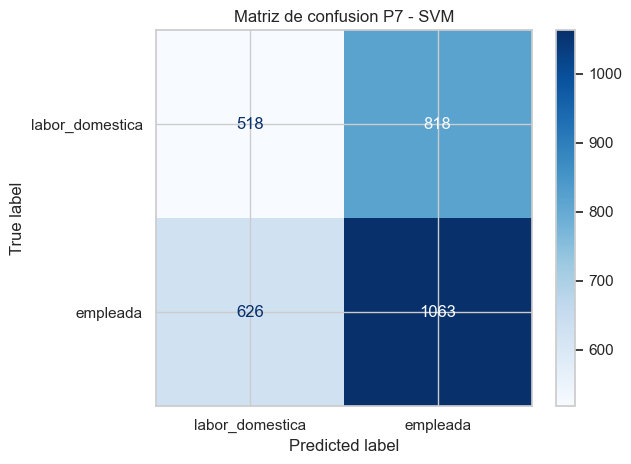

In [61]:
p7_model = clone(best_model)

start_time = time.perf_counter()
p7_model.fit(X_train_p7, y_train_p7)
p7_train_time = time.perf_counter() - start_time

y_pred_p7 = p7_model.predict(X_test_p7)

p7_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test_p7, y_pred_p7),
        "balanced_accuracy": balanced_accuracy_score(y_test_p7, y_pred_p7),
        "precision": precision_score(y_test_p7, y_pred_p7, zero_division=0),
        "recall": recall_score(y_test_p7, y_pred_p7, zero_division=0),
        "f1": f1_score(y_test_p7, y_pred_p7, zero_division=0),
        "time_seconds": p7_train_time,
    },
    name=f"{best_model_name} en cluster mayor IMCE",
)

print("Modelo reestimado en P7:", best_model_name)
print(p7_metrics.round(3))

print(
    classification_report(
        y_test_p7,
        y_pred_p7,
        labels=p5_labels,
        target_names=p5_target_names,
        zero_division=0,
    )
)

p7_cm = confusion_matrix(y_test_p7, y_pred_p7, labels=p5_labels)

p7_disp = ConfusionMatrixDisplay(
    confusion_matrix=p7_cm,
    display_labels=p5_target_names,
)
p7_disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matriz de confusion P7 - {best_model_name}")
plt.tight_layout()
plt.show()

In [62]:
p7_comparison = pd.DataFrame(
    [
        p5_results.loc[best_model_name],
        p7_metrics,
    ],
    index=["P5 muestra completa", "P7 cluster mayor IMCE"],
)

print(p7_comparison.round(3))

metric_diff_p7 = p7_comparison.loc["P7 cluster mayor IMCE"] - p7_comparison.loc["P5 muestra completa"]
metric_diff_p7.name = "Diferencia P7 - P5"

print(metric_diff_p7.round(3).to_frame())

if hasattr(p7_model, "feature_importances_"):
    p7_feature_importance = pd.Series(
        p7_model.feature_importances_,
        index=factor_cols,
        name="importance",
    ).sort_values(ascending=False)

    print(p7_feature_importance.round(3).to_frame())

    plt.figure(figsize=(7, 4))
    plt.barh(
        p7_feature_importance.sort_values().index,
        p7_feature_importance.sort_values().values,
        color="#2a6fbb",
    )
    plt.title(f"Importancia de factores P7 - {best_model_name}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()


                       accuracy  balanced_accuracy  precision  recall     f1  time_seconds
P5 muestra completa       0.530              0.518      0.561   0.644  0.600         1.966
P7 cluster mayor IMCE     0.523              0.509      0.565   0.629  0.596         0.065
                   Diferencia P7 - P5
accuracy                       -0.007
balanced_accuracy              -0.010
precision                       0.004
recall                         -0.015
f1                             -0.004
time_seconds                   -1.902


R P7: Para esta pregunta se tomo el cluster 1 de Kmeans el cual es el cluster con mayor imce promedio y contiene 16.911 observaciones equivalente al 40.4% de la muestra. Este grupo tiene un imce promedio de 2.225, muy por encima del resto de clusters y una actividad fisica promedio de 2.244 es decir baja-intermedia.

Luego se filtró este grupo y se excluyeron nuevamente las madres desempleadas, igual que en las preguntas anteriores. Después de este filtro quedaron 15.123 observaciones: 6.679 de labor doméstica y 8.444 de madres empleadas. La proporción de clases se mantuvo parecida a la muestra original, con 44.16% para labor doméstica y 55.84% para empleada. El conjunto se dividió nuevamente en entrenamiento y prueba, usando las mismas variables factoriales: affectionate_gang, curiosity_gang y friendly_gang.

Como el mejor modelo de la Pregunta 5 fue SVM, se reestimó este modelo dentro del cluster de mayor IMCE. En esta submuestra, el modelo obtuvo un accuracy de 0.523, un balanced_accuracy de 0.509, una precision de 0.565, un recall de 0.629 y un f1 de 0.596. Estos resultados siguen siendo bajos, especialmente porque el balanced_accuracy continúa muy cercano a 0.5, lo que indica que el modelo apenas distingue entre ambas clases.

Al comparar con el modelo de la Pregunta 5 usando la muestra completa, el desempeño no mejora. El accuracy baja de 0.530 a 0.523, el balanced_accuracy baja de 0.518 a 0.509, el recall baja de 0.644 a 0.629 y el f1 baja levemente de 0.600 a 0.596. La única mejora es mínima en precision, que sube de 0.561 a 0.565. En cambio, el tiempo de entrenamiento sí disminuye bastante, de 1.966 a 0.065 segundos, lo que se explica por el menor tamaño de la muestra.

En conclusión, restringir el análisis al grupo con mayor IMCE promedio no mejora la capacidad predictiva del modelo. El SVM sigue mostrando un desempeño débil y cercano al azar balanceado. Esto sugiere que, incluso dentro del grupo de niños con mayor IMCE, los factores socioemocionales estimados no permiten distinguir claramente entre madres empleadas y madres dedicadas a labor doméstica. La segmentación por IMCE sirve para describir un subgrupo específico, pero no parece aportar una mejora relevante para la clasificación

8. Revise el notebook Sentiment_Analysis.ipynb. Considere la variable *narrative* en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables *sk*. Compare y discuta sus resultados.

In [81]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords", quiet=True)
spanish_stopwords = set(stopwords.words("spanish"))
domain_stopwords = {
    "area",
    "areas",
    "observa",
    "observan",
    "muestra",
    "muestran",
    "registran",
    "registra",
    "destaca",
    "destacan",
    "aunque",
    "si",
    "solo",
    "manera",
    "nivel",
    "perfil",
    "diferencia",
    "diferencias",
    "socioemocional",
    "socioemocionales",
    "habilidad",
    "habilidades",
    "evaluadas",
    "evaluados",
    "cosas",
    "siendo",
    "hacia",
    "veces",
    "todavia",
    "bien",
    "estan",
    "exhibe",
    "alcanza",
    "evidencia",
    "resalta",
    "maneja",
    "clara",
    "ambitos",
    "tres",
}


spanish_stopwords = spanish_stopwords | domain_stopwords


In [82]:
df_text = df_model[df_model["madre_work"].isin([-1, 1])].copy()
df_text["target"] = (df_text["madre_work"] == 1).astype(int)

print("Nulos en narrative:")
print(df_text["narrative"].isna().sum())

print("\nDistribucion target texto:")
print(df_text["target"].value_counts().sort_index())
print((100 * df_text["target"].value_counts(normalize=True).sort_index()).round(2))

print(df_text[["narrative", "target"]].head())

Nulos en narrative:
0

Distribucion target texto:
target
0    17026
1    20519
Name: count, dtype: int64
target
0    45.35
1    54.65
Name: proportion, dtype: float64
                                           narrative  target
0  Las habilidades socioemocionales estan bien es...       0
1  Exhibe un perfil socioemocional muy solido, si...       1
2  Su perfil socioemocional aun esta madurando, s...       1
3  Alcanza un nivel socioemocional muy alto, de m...       0
5  Evidencia un desarrollo socioemocional excelen...       0


In [83]:
df_text["narrative_clean"] = (
    df_text["narrative"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-záéíóúñü\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_text["narrative_clean"] = df_text["narrative_clean"].apply(
    lambda text: " ".join(
        word for word in text.split() if word not in spanish_stopwords
    )
)

print(df_text[["narrative", "narrative_clean"]].head())

                                           narrative                                    narrative_clean
0  Las habilidades socioemocionales estan bien es...  establecidas afectivo emocional mas fuerte cur...
1  Exhibe un perfil socioemocional muy solido, si...  solido marcadas mejor juego mientras expresion...
2  Su perfil socioemocional aun esta madurando, s...  aun madurando interaccion social juego ambito ...
3  Alcanza un nivel socioemocional muy alto, de m...  alto homogenea particularmente uso gestos comu...
5  Evidencia un desarrollo socioemocional excelen...  desarrollo excelente ventaja interaccion socia...


In [84]:
X_train_text = df_text.loc[X_train.index, "narrative_clean"]
X_test_text = df_text.loc[X_test.index, "narrative_clean"]
y_train_text = df_text.loc[y_train.index, "target"]
y_test_text = df_text.loc[y_test.index, "target"]

print("Train texto:", X_train_text.shape, y_train_text.shape)
print("Test texto:", X_test_text.shape, y_test_text.shape)

print("\nDistribucion target train texto:")
print(y_train_text.value_counts(normalize=True).sort_index().round(3))

print("\nDistribucion target test texto:")
print(y_test_text.value_counts(normalize=True).sort_index().round(3))


Train texto: (30036,) (30036,)
Test texto: (7509,) (7509,)

Distribucion target train texto:
target
0    0.453
1    0.547
Name: proportion, dtype: float64

Distribucion target test texto:
target
0    0.453
1    0.547
Name: proportion, dtype: float64


In [85]:
text_svc = Pipeline(
    [
        (
            "vect",
            TfidfVectorizer(
                ngram_range=(1, 1),
                min_df=10,
                max_df=0.70,
                max_features=2000,
                sublinear_tf=True,
            ),
        ),
        (
            "svc",
            LinearSVC(
                class_weight="balanced",
                random_state=p5_random_state,
                max_iter=5000,
                dual=False,
            ),
        ),
    ]
)

start_time = time.perf_counter()
text_svc.fit(X_train_text, y_train_text)
p8_train_time = time.perf_counter() - start_time

y_pred_text = text_svc.predict(X_test_text)

p8_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test_text, y_pred_text),
        "balanced_accuracy": balanced_accuracy_score(y_test_text, y_pred_text),
        "precision": precision_score(y_test_text, y_pred_text, zero_division=0),
        "recall": recall_score(y_test_text, y_pred_text, zero_division=0),
        "f1": f1_score(y_test_text, y_pred_text, zero_division=0),
        "time_seconds": p8_train_time,
    },
    name="SVC texto narrative",
)

print("SVC textual con narrative")
print(p8_metrics.round(3))

print(
    classification_report(
        y_test_text,
        y_pred_text,
        labels=p5_labels,
        target_names=p5_target_names,
        zero_division=0,
    )
)

SVC textual con narrative
accuracy             0.524
balanced_accuracy    0.521
precision            0.566
recall               0.558
f1                   0.562
time_seconds         1.589
Name: SVC texto narrative, dtype: float64
                 precision    recall  f1-score   support

labor_domestica       0.48      0.48      0.48      3405
       empleada       0.57      0.56      0.56      4104

       accuracy                           0.52      7509
      macro avg       0.52      0.52      0.52      7509
   weighted avg       0.52      0.52      0.52      7509



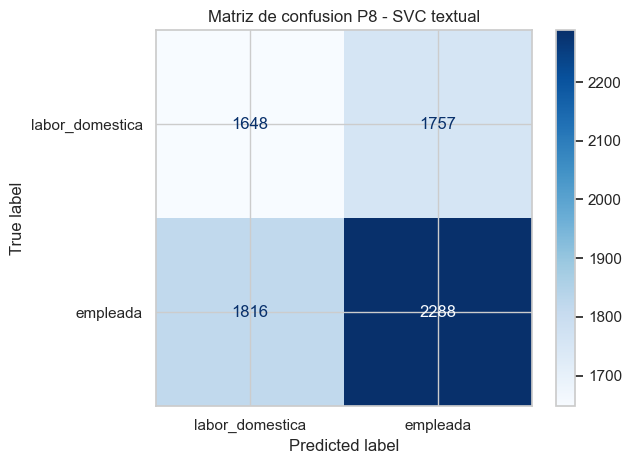

In [88]:
p8_cm = confusion_matrix(y_test_text, y_pred_text, labels=p5_labels)

p8_disp = ConfusionMatrixDisplay(
    confusion_matrix=p8_cm,
    display_labels=p5_target_names,
)
p8_disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusion P8 - SVC textual")
plt.tight_layout()
plt.show()

In [86]:
p8_comparison = pd.DataFrame(
    [
        p5_results.loc["SVM"],
        p8_metrics,
    ],
    index=["P5 SVM factores", "P8 SVC texto"],
)

print(p8_comparison.round(3))

metric_diff_p8 = p8_comparison.loc["P8 SVC texto"] - p8_comparison.loc["P5 SVM factores"]
metric_diff_p8.name = "Diferencia P8 - P5 SVM"

print(metric_diff_p8.round(3).to_frame())

                 accuracy  balanced_accuracy  precision  recall     f1  time_seconds
P5 SVM factores     0.530              0.518      0.561   0.644  0.600         1.966
P8 SVC texto        0.524              0.521      0.566   0.558  0.562         1.589
                   Diferencia P8 - P5 SVM
accuracy                           -0.006
balanced_accuracy                   0.003
precision                           0.005
recall                             -0.087
f1                                 -0.038
time_seconds                       -0.378


In [87]:
text_vect = text_svc.named_steps["vect"]
text_svc_model = text_svc.named_steps["svc"]

coef_values = text_svc_model.coef_
if hasattr(coef_values, "toarray"):
    coef_values = coef_values.toarray().ravel()
else:
    coef_values = coef_values.ravel()

text_coef = pd.DataFrame(
    {
        "term": text_vect.get_feature_names_out(),
        "coef": coef_values,
    }
).sort_values("coef")

print("Clases del SVC textual:", text_svc_model.classes_)
print("Coeficientes negativos empujan hacia labor_domestica; positivos hacia empleada.")

print("\nTerminos mas asociados a labor_domestica:")
print(text_coef.head(15).round(3))

print("\nTerminos mas asociados a empleada:")
print(text_coef.tail(15).sort_values("coef", ascending=False).round(3))

Clases del SVC textual: [0 1]
Coeficientes negativos empujan hacia labor_domestica; positivos hacia empleada.

Terminos mas asociados a labor_domestica:
             term   coef
7     agresividad -0.608
41        debiles -0.550
76     incipiente -0.494
78        inicial -0.478
5      afianzadas -0.471
118       proceso -0.440
31   competencias -0.418
40          debil -0.361
65      fortaleza -0.356
58       estimulo -0.272
124      requiere -0.272
130     sobresale -0.241
20            aun -0.238
79    interaccion -0.212
132        social -0.212

Terminos mas asociados a empleada:
            term   coef
27        brotes  0.834
4         afecto  0.754
56    esporadica  0.732
116     presenta  0.637
84         juego  0.610
66     frecuente  0.500
67    frecuentes  0.439
36     constante  0.408
103  ocasionales  0.402
52     episodios  0.402
87        libros  0.390
21       ausente  0.386
51       entorno  0.380
30     compartir  0.353
60     excelente  0.346


R P8: En esta pregunta se utilizó la variable narrative como única fuente de información textual para clasificar madre_work, excluyendo nuevamente a las madres desempleadas para mantener el problema binario entre labor_domestica y empleada. A diferencia de los modelos anteriores, no se usaron directamente las variables sk, sino una representación de texto basada en las narrativas generadas a partir de ellas.

Para procesar el texto se siguió la lógica del notebook Sentiment_Analysis.ipynb: se limpió el texto pasando todo a minúsculas, eliminando caracteres especiales y removiendo stopwords en español. Además, se agregaron algunas stopwords propias del dominio, como palabras muy repetidas o poco informativas dentro de las narrativas. Luego se usó TfidfVectorizer para transformar el texto en variables numéricas y se entrenó un modelo LinearSVC.

El modelo textual obtuvo un accuracy de 0.524, un balanced_accuracy de 0.521, una precision de 0.566, un recall de 0.558 y un f1 de 0.562. Estos resultados muestran un desempeño bajo, aunque levemente superior al azar. A diferencia de algunos modelos anteriores, el modelo textual reparte mejor el desempeño entre ambas clases: el recall fue 0.48 para labor doméstica y
0.56 para empleada.

Al compararlo con el SVM de la Pregunta 5 usando factores numéricos, el modelo textual tuvo menor accuracy (0.524 frente a 0.530) y menor f1 (0.562 frente a 0.600). Sin embargo, tuvo un balanced_accuracy levemente mayor (0.521 frente a 0.518), lo que indica que clasificó de forma un poco más equilibrada ambas clases. La diferencia es pequeña, por lo que no se puede afirmar que el texto mejore claramente al modelo con factores.

Los coeficientes del modelo muestran que algunos términos como agresividad, debiles, incipiente, inicial, requiere o estimulo se asociaron más con la clase labor_domestica, mientras que palabras como afecto, juego, compartir, entorno, libros o excelente se asociaron más con la clase empleada. Estas asociaciones son interesantes, pero deben interpretarse con cautela, ya que el desempeño general del modelo sigue siendo bajo.

En conclusión, el uso de narrative permite obtener un modelo textual con desempeño comparable al SVM basado en factores, pero no entrega una mejora sustantiva. Esto puede deberse a que la variable narrative fue generada a partir de las mismas variables socioemocionales sk, por lo que no aporta información completamente nueva. Por lo tanto, el modelo textual sirve como contraste metodológico, pero no cambia la conclusión general: las variables socioemocionales tienen poca capacidad para distinguir claramente entre madres empleadas y madres dedicadas a labor doméstica.